# Fig.2 : WT thermal activity

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pingouin as pg
import scikit_posthocs as sp
import h5py
import zarr
import logging
import statsmodels.api as sm

from pathlib import Path
from numpy import typing as npt
from typing import TYPE_CHECKING
from matplotlib import rcParams
from scipy.stats import sem, wilcoxon, shapiro, chi2_contingency, fisher_exact
from scipy.signal import butter, filtfilt, savgol_filter
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from itertools import combinations

### Directory for fig saving

In [2]:
# Définir le chemin de base et le répertoire à créer
base_dir = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator"
saving_dir = os.path.join(base_dir, "Plot_Fig_2_WT_Thq")

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(saving_dir):
    os.makedirs(saving_dir)
    print(f"Le répertoire '{saving_dir}' a été créé avec succès.")
else:
    print(f"Le répertoire '{saving_dir}' existe déjà.")

Le répertoire 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_2_WT_Thq' existe déjà.


For svg texte

In [3]:
# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# plt.rcParams.update({
#     'axes.labelsize': 16,   # Taille des labels des axes
#     'xtick.labelsize': 16,  # Taille des labels des ticks sur l'axe x
#     'ytick.labelsize': 16,  # Taille des labels des ticks sur l'axe y
#     'legend.fontsize': 10   # Taille de la police de la légende
# })

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 18,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 12   # Taille de la police de la légende
})

#

### Fig 2.B - Exemple rec for thermic cool stim one shank

In [4]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.06"
sel_rec = 'allego_3__uid0206-14-15-34'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_3__uid0206-14-15-34
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_3__uid0206-14-15-34

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_3__uid0206-14-15-34\allego_3__uid0206-14-15-34_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.06\allego_3__uid0206-14-15-34
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.06\allego_3__uid0206-14-15-34\allego_3__uid0206-14-15-34_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_3__uid0206-14

In [5]:
####### LFPs + ADCs from zarr #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2
select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0


####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")


####### Selection des neurones valides ######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]

####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]


def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """

    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    # n_stims = np.sum(valid_up)
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end


t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp15_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)



####### Infer ascending and descending phases #######
thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

# ####### Parameters for the PSTH #######
win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus



####### Définir les périodes pour chaque stimulus #######
time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }



In [6]:
# This is to plot the temperature profile on the raster
mask_raster = t_lfps > descending_start[0] - dt_before - 10
mask_raster &= t_lfps < descending_start[0] + dt_after + 10
t_plot_raster = t_lfps[mask_raster] - descending_start[0]
temp_plot_raster = therm_stim[mask_raster]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed_raster = moving_average(temp_plot_raster, window_size)

min : -81.05750274658203, max : 77.04219055175781
Valeur minimale arrondie: -90.0, Valeur maximale arrondie: 80.0


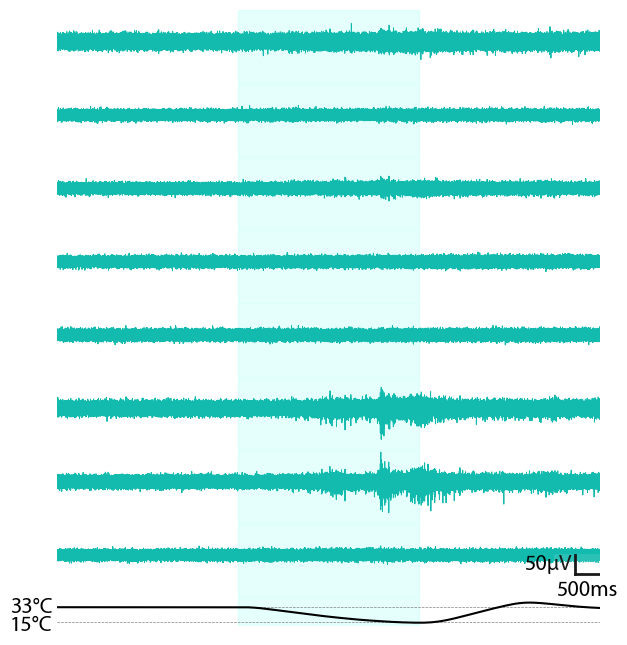

In [7]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels] 

id_stim = 3

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = descending_end[id_stim]

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration
end_time = stim_end + stim_duration

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Calculer les limites de l'axe Y
y_max = np.max(data_to_plot_reversed)
y_min = np.min(data_to_plot_reversed)

y_max_rounded = np.ceil(y_max / 10) * 10
y_min_rounded = np.floor(y_min / 10) * 10

print(f"min : {y_min}, max : {y_max}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_to_plot_reversed[:, i], color="#13bbaf", linewidth=0.7, alpha=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#cafffb', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(-108.42, 82.80)
    # axs[i].set_ylim(y_min_tac, y_max_tac)
    # axs[i].set_ylim(y_min, y_max)

# === Tracer la temp subplot ===

# Tracer les signaux des électrodes
for i in range(n_stims):
    # Masque ajusté pour les données de température
    mask = (t_lfps >= time.min()) & (t_lfps <= time.max())  # S'assurer que t_lfps est dans la plage de 'time'
    # Appliquer la condition de stimulation pour la température
    mask &= (t_lfps > t_stim_start[id_stim] - 2 * stim_duration) & (t_lfps < t_stim_start[id_stim] + 2 * stim_duration)
    # Extraire les données de température basées sur le masque ajusté
    t_plot = t_lfps[mask] - t_stim_start[id_stim]  # Décalage pour aligner la période de stimulation
    t_plot = t_plot - t_plot.min() + time.min()
    temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Paramètres de la fenêtre de lissage
window_size = 5  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Tracage de la température
axs[-1].plot(t_plot[window_size-1:], temp_plot_smoothed, color='k', linewidth=1.5)  # Aligner le temps avec les données lissées

# Réajuster la plage temporelle de la période de stimulation
axs[-1].axvspan(stim_start, stim_end, color='#cafffb', alpha=0.5, label='Cool stim', zorder=0)

# Ré-ajuster les limites de x et y sur axs[-1]
axs[-1].set_xlim(time.min(), time.max())
axs[-1].tick_params(axis='y', which='both', length=0)
axs[-1].set_yticks([13, 35])
axs[-1].set_yticklabels(['15°C', '33°C'], fontsize=16)
axs[-1].set_ylim(10, 46)

# Ajouter deux lignes horizontales fines à y = 33 et y = 15
axs[-1].axhline(y=33, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 33
axs[-1].axhline(y=15, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 15


# Supprimer l'axe des X et les bordures du haut et droite
axs[-1].get_xaxis().set_visible(False)  # Cache l'axe des X
axs[-1].spines['top'].set_visible(False)  # Cache la bordure du haut
axs[-1].spines['right'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['bottom'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['left'].set_visible(False)  # Cache la bordure de droite



# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.2  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=20)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 0.5 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=16)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 17, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 50  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=16)
axs[shank_id].text(origin_x - 1, (origin_y + amp_y_end) / 2, "50µV", fontsize=16, ha='left', va='center')


# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2B_WT_cool_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2B_WT_cool_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

### Fig 2.Bbis - Exemple LFP rec for thermic cool stim one shank

In [22]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.06"
sel_rec = 'allego_33__uid0206-14-15-34'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_33__uid0206-14-15-34
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_33__uid0206-14-15-34

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_33__uid0206-14-15-34\allego_33__uid0206-14-15-34_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.06\allego_33__uid0206-14-15-34
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.06\allego_33__uid0206-14-15-34\allego_33__uid0206-14-15-34_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_33__ui

In [23]:
####### LFPs + ADCs from zarr #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2
select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0


####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")


####### Selection des neurones valides ######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]

####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]


def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """

    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    # n_stims = np.sum(valid_up)
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end


t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp15_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)



####### Infer ascending and descending phases #######
thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

# ####### Parameters for the PSTH #######
win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus



####### Définir les périodes pour chaque stimulus #######
time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }



In [24]:
# This is to plot the temperature profile on the raster
mask_raster = t_lfps > descending_start[0] - dt_before - 10
mask_raster &= t_lfps < descending_start[0] + dt_after + 10
t_plot_raster = t_lfps[mask_raster] - descending_start[0]
temp_plot_raster = therm_stim[mask_raster]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed_raster = moving_average(temp_plot_raster, window_size)

min : -246.14382213027474, max : 183.33692799083906
Valeur minimale arrondie: -250.0, Valeur maximale arrondie: 190.0


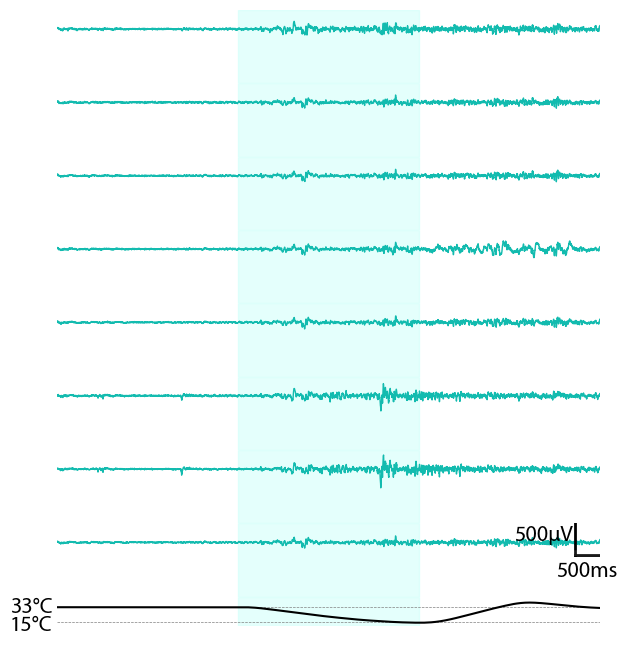

In [11]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels] 

id_stim = 3

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = descending_end[id_stim]

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration
end_time = stim_end + stim_duration

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Fonction pour appliquer un filtre passe-bas
def lowpass_filter(data, cutoff=200, fs=30000, order=4):
    nyquist = 0.5 * fs  # Fréquence de Nyquist
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data, axis=0)

# Appliquer le filtrage passe-bas Butterworth
data_filtered = lowpass_filter(data_to_plot_reversed)

# Appliquer le filtre Savitzky-Golay (fenêtre = 101, polynôme = 3)
data_filtered_savgol = savgol_filter(data_filtered, window_length=101, polyorder=3, axis=0)


# Calculer les limites de l'axe Y
y_max = np.max(data_filtered_savgol)
y_min = np.min(data_filtered_savgol)


y_max_rounded = np.ceil(y_max / 10) * 10
y_min_rounded = np.floor(y_min / 10) * 10

print(f"min : {y_min}, max : {y_max}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_filtered_savgol[:, i], color="#13bbaf", linewidth=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#cafffb', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(-710, 250)
    # axs[i].set_ylim(y_min_tac, y_max_tac)
    # axs[i].set_ylim(y_min, y_max)

# === Tracer la temp subplot ===

# Tracer les signaux des électrodes
for i in range(n_stims):
    # Masque ajusté pour les données de température
    mask = (t_lfps >= time.min()) & (t_lfps <= time.max())  # S'assurer que t_lfps est dans la plage de 'time'
    # Appliquer la condition de stimulation pour la température
    mask &= (t_lfps > t_stim_start[id_stim] - 2 * stim_duration) & (t_lfps < t_stim_start[id_stim] + 2 * stim_duration)
    # Extraire les données de température basées sur le masque ajusté
    t_plot = t_lfps[mask] - t_stim_start[id_stim]  # Décalage pour aligner la période de stimulation
    t_plot = t_plot - t_plot.min() + time.min()
    temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Paramètres de la fenêtre de lissage
window_size = 5  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Tracage de la température
axs[-1].plot(t_plot[window_size-1:], temp_plot_smoothed, color='k', linewidth=1.5)  # Aligner le temps avec les données lissées

# Réajuster la plage temporelle de la période de stimulation
axs[-1].axvspan(stim_start, stim_end, color='#cafffb', alpha=0.5, label='Cool stim', zorder=0)

# Ré-ajuster les limites de x et y sur axs[-1]
axs[-1].set_xlim(time.min(), time.max())
axs[-1].tick_params(axis='y', which='both', length=0)
axs[-1].set_yticks([13, 35])
axs[-1].set_yticklabels(['15°C', '33°C'], fontsize=16)
axs[-1].set_ylim(10, 46)

# Ajouter deux lignes horizontales fines à y = 33 et y = 15
axs[-1].axhline(y=33, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 33
axs[-1].axhline(y=15, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 15


# Supprimer l'axe des X et les bordures du haut et droite
axs[-1].get_xaxis().set_visible(False)  # Cache l'axe des X
axs[-1].spines['top'].set_visible(False)  # Cache la bordure du haut
axs[-1].spines['right'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['bottom'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['left'].set_visible(False)  # Cache la bordure de droite



# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.2  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=20)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 0.5 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=16)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 100, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 500  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=16)
axs[shank_id].text(origin_x - 1.2, (origin_y + amp_y_end) / 2, "500µV", fontsize=16, ha='left', va='center')


# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

#Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2Bbis_WT_cool_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2Bbis_WT_cool_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 2.C - Exemple raster for thermic cool stim one neuron (8 stim)

Cluster : temp_77


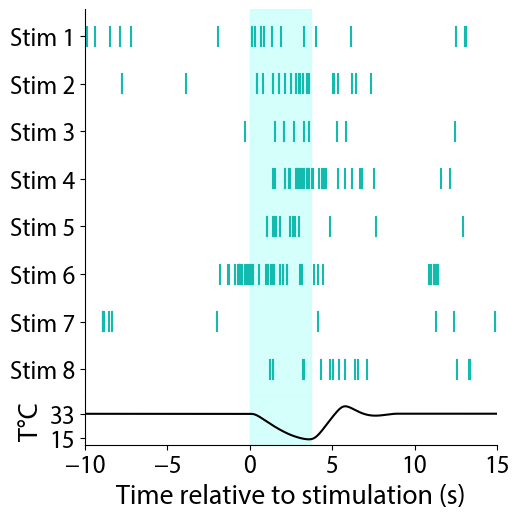

In [25]:
# Paramètres
time_before_stim = 10  # 10 secondes avant le début du stimulus
time_after_stim = 15   # 15 secondes après le début du stimulus

# Sélectionner un valid_key
valid_key = valid_keys[15]  # Choisir un seul neurone
print(f'Cluster : {valid_key}')

# Récupérer les spikes pour ce neurone spécifique
spikes = dataset['spiketimes'][valid_key]

# === Création des subplots ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [8, 1]})

# Tracer les spikes pour chaque stimulus
for i in range(len(t_stim_start)):  # Pour chaque stimulus (de 1 à 8)
    stim_start = t_stim_start[i]
    stim_end = t_stim_end[i]

    # Définir la fenêtre d'intérêt autour du stimulus (10 secondes avant et après)
    window_start = stim_start - time_before_stim
    window_end = stim_end + time_after_stim

    # Sélectionner les spikes dans cette fenêtre et les aligner par rapport au début du stimulus
    selected_spikes = [spike - stim_start for spike in spikes if window_start <= spike <= window_end]

    # Tracer les spikes alignés pour ce stimulus
    for spike in selected_spikes:
        ax1.plot([spike, spike], [i + 0.2, i - 0.2], color='#13bbaf')  # Ligne verticale pour chaque spike

# Paramétrage du raster plot
ax1.set_ylabel('')  # Label de l'axe Y

# Inverser l'ordre des ticks de l'axe Y et l'axe Y
ax1.set_yticks(range(len(t_stim_start)-1, -1, -1))  # Inverser l'ordre des ticks
ax1.set_yticklabels([f'Stim {i+1}' for i in range(len(t_stim_start)-1, -1, -1)])  # Labels des stimuli inversés

# Limiter l'axe des x pour afficher la fenêtre autour du stimulus
ax1.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Inverser l'axe Y pour avoir Stim 1 en haut et Stim 8 en bas
ax1.invert_yaxis()  # Inverse l'axe Y

ax1.axvspan(0, 3.7, color='#cafffb', alpha=0.8, label='Tactile stim', zorder=0)

# Suppression des bordures superflues
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.get_xaxis().set_visible(False)  # Cache l'axe des X


# === Tracer les pulses tactiles en dernier subplot ===
# **Deuxième subplot : Température**
ax2.plot(t_plot_raster, temp_plot_smoothed_raster, color='k',  linewidth=1.5)
ax2.axvspan(0, 3.7, color='#cafffb', alpha=0.8, label='Tactile stim', zorder=0)
ax2.set_ylabel("T°C")
ax2.set_xlabel("Time relative to stimulation (s)")
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])
ax2.set_ylim(10, 46)
ax2.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Suppression des bordures superflues
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustements finaux
plt.tight_layout(pad=0.001, h_pad=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2C_WT_cool_cont_raster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2C_WT_cool_cont_raster.svg'), format='svg', dpi=300)

plt.show()


#

### Fig 2.D - Exemple rec for thermic warm stim one shank

In [13]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.06"
sel_rec = 'allego_2__uid0206-14-03-33'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_2__uid0206-14-03-33
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_2__uid0206-14-03-33

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_2__uid0206-14-03-33\allego_2__uid0206-14-03-33_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.06\allego_2__uid0206-14-03-33
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.06\allego_2__uid0206-14-03-33\allego_2__uid0206-14-03-33_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_2__uid0206-14

In [14]:
####### LFPs + ADCs from zarr #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2
select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0

####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")

####### Selection des neurones valides #######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]

####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]

def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """
    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end

t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp46_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)

####### Infer ascending and descending phases #######
thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

######## Parameters for the PSTH #######
win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus


####### Définir les périodes pour chaque stimulus #######
time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }

In [15]:
# This is to plot the temperature profile on the raster
mask_raster = t_lfps > descending_start[0] - dt_before - 10
mask_raster &= t_lfps < descending_start[0] + dt_after + 10
t_plot_raster = t_lfps[mask_raster] - descending_start[0]
temp_plot_raster = therm_stim[mask_raster]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed_raster = moving_average(temp_plot_raster, window_size)

min : -79.61416625976562, max : 50.63581085205078
Valeur minimale arrondie: -80.0, Valeur maximale arrondie: 60.0


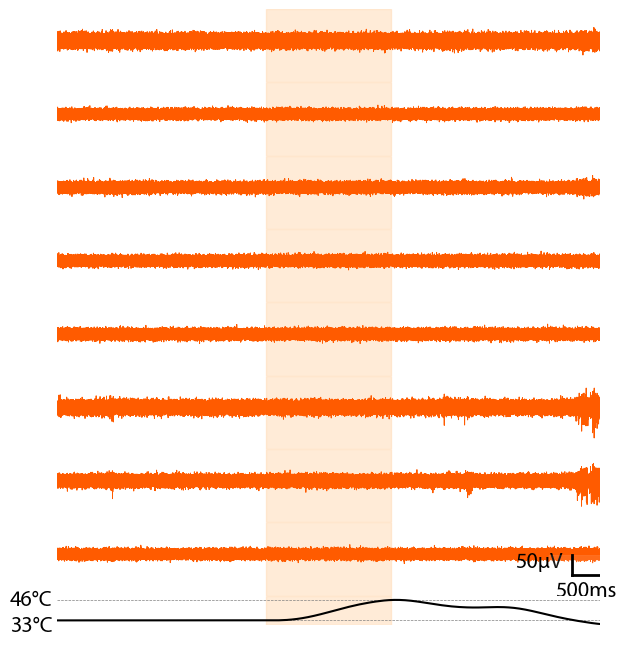

In [16]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels] 

id_stim = 7

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = stim_start + 2.2

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration - 1.5
end_time = stim_end + stim_duration + 1.5

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Calculer les limites de l'axe Y
y_max = np.max(data_to_plot_reversed)
y_min = np.min(data_to_plot_reversed)

y_max_rounded = np.ceil(y_max / 10) * 10
y_min_rounded = np.floor(y_min / 10) * 10

print(f"min : {y_min}, max : {y_max}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_to_plot_reversed[:, i], color="#ff5b00", linewidth=0.7, alpha=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#ffd8b1', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(-108.42, 82.80)
    # axs[i].set_ylim(y_min_tac, y_max_tac)


# === Tracer la temp subplot ===

# Tracer les signaux des électrodes
for i in range(n_stims):
    # Masque ajusté pour les données de température
    mask = (t_lfps >= time.min()) & (t_lfps <= time.max())  # S'assurer que t_lfps est dans la plage de 'time'
    # Appliquer la condition de stimulation pour la température
    mask &= (t_lfps > t_stim_start[id_stim] - 4 * stim_duration) & (t_lfps < t_stim_start[id_stim] + 4 * stim_duration)
    # Extraire les données de température basées sur le masque ajusté
    t_plot = t_lfps[mask] - t_stim_start[id_stim]  # Décalage pour aligner la période de stimulation
    t_plot = t_plot - t_plot.min() + time.min()
    temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Paramètres de la fenêtre de lissage
window_size = 5  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Tracage de la température
axs[-1].plot(t_plot[window_size-1:], temp_plot_smoothed, color='k', linewidth=1.5)  # Aligner le temps avec les données lissées

# Réajuster la plage temporelle de la période de stimulation
axs[-1].axvspan(stim_start, stim_end, color='#ffd8b1', alpha=0.5, label='Cool stim', zorder=0)

# Ré-ajuster les limites de x et y sur axs[-1]
axs[-1].set_xlim(time.min(), time.max())
axs[-1].tick_params(axis='y', which='both', length=0)
axs[-1].set_yticks([31, 48])
axs[-1].set_yticklabels(['33°C', '46°C'], fontsize=16)
axs[-1].set_ylim(30, 49)

# Ajouter deux lignes horizontales fines à y = 33 et y = 15
axs[-1].axhline(y=33, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 33
axs[-1].axhline(y=46, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 15


# Supprimer l'axe des X et les bordures du haut et droite
axs[-1].get_xaxis().set_visible(False)  # Cache l'axe des X
axs[-1].spines['top'].set_visible(False)  # Cache la bordure du haut
axs[-1].spines['right'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['bottom'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['left'].set_visible(False)  # Cache la bordure de droite



# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.2  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=10)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 0.5 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 17, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 50  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
axs[shank_id].text(origin_x - 1, (origin_y + amp_y_end) / 2 + 10, "50µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2D_WT_warm_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2D_WT_warm_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 2.Dbis - Exemple LFP rec for thermic warm stim one shank

In [17]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.06"
sel_rec = 'allego_22__uid0206-14-03-33'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_22__uid0206-14-03-33
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_22__uid0206-14-03-33

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_22__uid0206-14-03-33\allego_22__uid0206-14-03-33_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.06\allego_22__uid0206-14-03-33
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.06\allego_22__uid0206-14-03-33\allego_22__uid0206-14-03-33_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_22__ui

In [18]:
####### LFPs + ADCs from zarr #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2
select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0

####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")

####### Selection des neurones valides #######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]

####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]

def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """
    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end

t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp46_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)

####### Infer ascending and descending phases #######
thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

######## Parameters for the PSTH #######
win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus


####### Définir les périodes pour chaque stimulus #######
time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }

In [19]:
# This is to plot the temperature profile on the raster
mask_raster = t_lfps > descending_start[0] - dt_before - 10
mask_raster &= t_lfps < descending_start[0] + dt_after + 10
t_plot_raster = t_lfps[mask_raster] - descending_start[0]
temp_plot_raster = therm_stim[mask_raster]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed_raster = moving_average(temp_plot_raster, window_size)

min : -182.97283471482106, max : 108.52806251298912
Valeur minimale arrondie: -190.0, Valeur maximale arrondie: 110.0


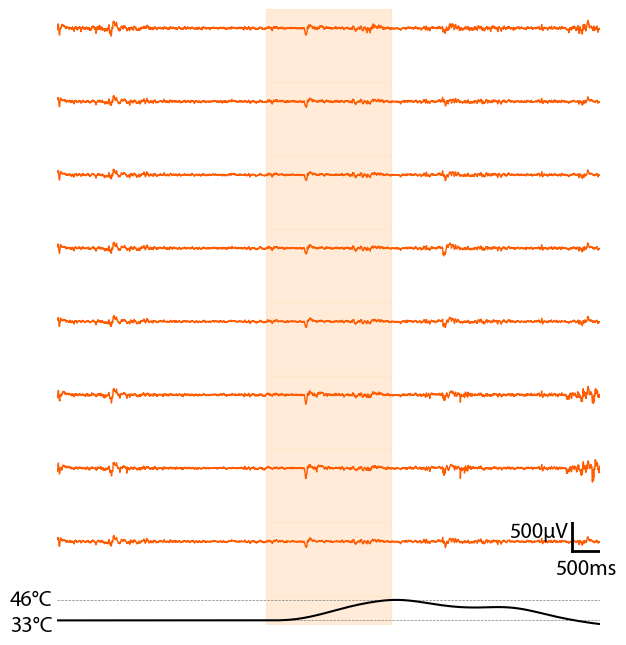

In [20]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels] 

id_stim = 7

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = stim_start + 2.2

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration - 1.5
end_time = stim_end + stim_duration + 1.5

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  


# Fonction pour appliquer un filtre passe-bas
def lowpass_filter(data, cutoff=200, fs=30000, order=4):
    nyquist = 0.5 * fs  # Fréquence de Nyquist
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data, axis=0)

# Appliquer le filtrage passe-bas Butterworth
data_filtered = lowpass_filter(data_to_plot_reversed)

# Appliquer le filtre Savitzky-Golay (fenêtre = 101, polynôme = 3)
data_filtered_savgol = savgol_filter(data_filtered, window_length=101, polyorder=3, axis=0)


# Calculer les limites de l'axe Y
y_max = np.max(data_filtered_savgol)
y_min = np.min(data_filtered_savgol)


y_max_rounded = np.ceil(y_max / 10) * 10
y_min_rounded = np.floor(y_min / 10) * 10

print(f"min : {y_min}, max : {y_max}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_filtered_savgol[:, i], color="#ff5b00", linewidth=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#ffd8b1', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(-710, 250)
    # axs[i].set_ylim(y_min_tac, y_max_tac)


# === Tracer la temp subplot ===

# Tracer les signaux des électrodes
for i in range(n_stims):
    # Masque ajusté pour les données de température
    mask = (t_lfps >= time.min()) & (t_lfps <= time.max())  # S'assurer que t_lfps est dans la plage de 'time'
    # Appliquer la condition de stimulation pour la température
    mask &= (t_lfps > t_stim_start[id_stim] - 4 * stim_duration) & (t_lfps < t_stim_start[id_stim] + 4 * stim_duration)
    # Extraire les données de température basées sur le masque ajusté
    t_plot = t_lfps[mask] - t_stim_start[id_stim]  # Décalage pour aligner la période de stimulation
    t_plot = t_plot - t_plot.min() + time.min()
    temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Paramètres de la fenêtre de lissage
window_size = 5  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Tracage de la température
axs[-1].plot(t_plot[window_size-1:], temp_plot_smoothed, color='k', linewidth=1.5)  # Aligner le temps avec les données lissées

# Réajuster la plage temporelle de la période de stimulation
axs[-1].axvspan(stim_start, stim_end, color='#ffd8b1', alpha=0.5, label='Cool stim', zorder=0)

# Ré-ajuster les limites de x et y sur axs[-1]
axs[-1].set_xlim(time.min(), time.max())
axs[-1].tick_params(axis='y', which='both', length=0)
axs[-1].set_yticks([31, 48])
axs[-1].set_yticklabels(['33°C', '46°C'], fontsize=16)
axs[-1].set_ylim(30, 49)

# Ajouter deux lignes horizontales fines à y = 33 et y = 15
axs[-1].axhline(y=33, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 33
axs[-1].axhline(y=46, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 15


# Supprimer l'axe des X et les bordures du haut et droite
axs[-1].get_xaxis().set_visible(False)  # Cache l'axe des X
axs[-1].spines['top'].set_visible(False)  # Cache la bordure du haut
axs[-1].spines['right'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['bottom'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['left'].set_visible(False)  # Cache la bordure de droite



# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.2  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=10)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 0.5 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 100, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 500  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
axs[shank_id].text(origin_x - 1.1, (origin_y + amp_y_end) / 2 + 10, "500µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2Dbis_WT_warm_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2Dbis_WT_warm_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 2.E - Exemple raster for thermic warm stim one neuron (8 stim)

Cluster : temp_13


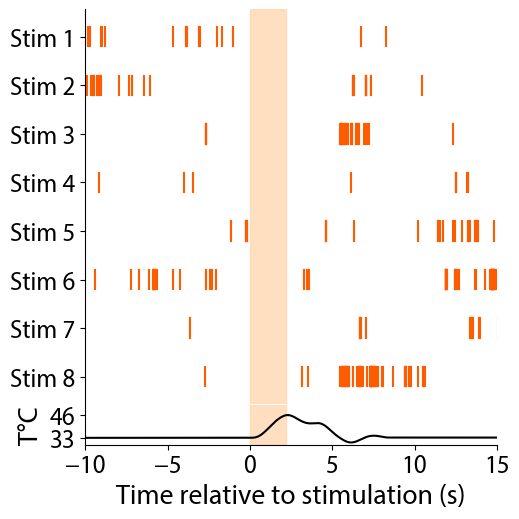

In [21]:
# Paramètres
time_before_stim = 10  # 10 secondes avant le début du stimulus
time_after_stim = 15   # 15 secondes après le début du stimulus

# Sélectionner un valid_key
valid_key = valid_keys[3]  # Choisir un seul neurone
print(f'Cluster : {valid_key}')

# Récupérer les spikes pour ce neurone spécifique
spikes = dataset['spiketimes'][valid_key]

# === Création des subplots ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [10, 1]})

# Tracer les spikes pour chaque stimulus
for i in range(len(t_stim_start)):  # Pour chaque stimulus (de 1 à 8)
    stim_start = t_stim_start[i]
    stim_end = t_stim_end[i]

    # Définir la fenêtre d'intérêt autour du stimulus (10 secondes avant et après)
    window_start = stim_start - time_before_stim
    window_end = stim_end + time_after_stim

    # Sélectionner les spikes dans cette fenêtre et les aligner par rapport au début du stimulus
    selected_spikes = [spike - stim_start for spike in spikes if window_start <= spike <= window_end]

    # Tracer les spikes alignés pour ce stimulus
    for spike in selected_spikes:
        ax1.plot([spike, spike], [i + 0.2, i - 0.2], color='#ff5b00')  # Ligne verticale pour chaque spike

# Paramétrage du raster plot
ax1.set_ylabel('')  # Label de l'axe Y

# Inverser l'ordre des ticks de l'axe Y et l'axe Y
ax1.set_yticks(range(len(t_stim_start)-1, -1, -1))  # Inverser l'ordre des ticks
ax1.set_yticklabels([f'Stim {i+1}' for i in range(len(t_stim_start)-1, -1, -1)])  # Labels des stimuli inversés

# Limiter l'axe des x pour afficher la fenêtre autour du stimulus
ax1.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Inverser l'axe Y pour avoir Stim 1 en haut et Stim 8 en bas
ax1.invert_yaxis()  # Inverse l'axe Y

ax1.axvspan(0, 2.2, color='#ffd8b1', alpha=0.8, label='Warm stim', zorder=0)

# Suppression des bordures superflues
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.get_xaxis().set_visible(False)  # Cache l'axe des X


# === Tracer les pulses tactiles en dernier subplot ===
# **Deuxième subplot : Température**
ax2.plot(t_plot_raster, temp_plot_smoothed_raster, color='k',  linewidth=1.5)
ax2.axvspan(0, 2.2, color='#ffd8b1', alpha=0.8, label='Tactile stim', zorder=0)
ax2.set_ylabel("T°C")
ax2.set_xlabel("Time relative to stimulation (s)")
ax2.set_yticks([33, 46])
ax2.set_yticklabels(['33', '46'])
ax2.set_ylim([29, 52])
ax2.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Suppression des bordures superflues
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustements finaux
plt.tight_layout(pad=0.0001, h_pad=0.0001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2E_WT_warm_cont_raster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2E_WT_warm_cont_raster.svg'), format='svg', dpi=300)

plt.show()


#

### Fig 2.F - response rate Thermic cool and warm contra vs ipsi

Directories communs à toutes les conditions : {'2024.01.31', '2024.05.29', '2024.05.22', '2024.05.28_M2', '2024.03.01', '2024.05.28_M1', '2024.02.06', '2024.03.05'}
n Cool_Cont = 8
n Cool_Ipsi = 8
n Warm_Cont = 8
n Warm_Ipsi = 8


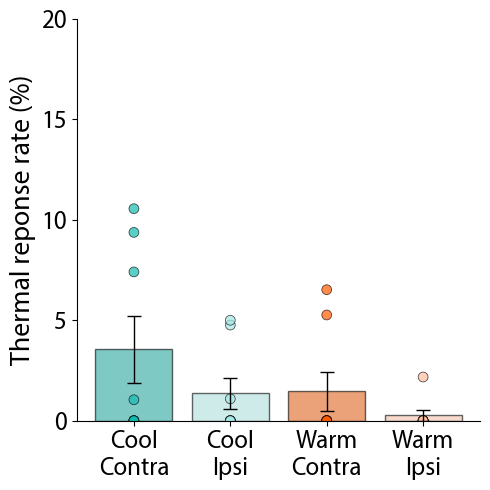


Cool_Cont : mean = 3.55 ± 1.66
Cool_Ipsi : mean = 1.36 ± 0.78

Warm_Cont : mean = 1.47 ± 0.97
Warm_Ipsi : mean = 0.27 ± 0.27
Cool_Cont: n_cluster = 4
Cool_Ipsi: n_cluster = 4
Warm_Cont: n_cluster = 4
Warm_Ipsi: n_cluster = 4
{'Cool_Cont':         directory                    file_name  response_percentage
0      2024.01.31   allego_0__uid0131-13-33-10             0.000000
1      2024.01.31   allego_7__uid0131-15-25-51             0.000000
2      2024.01.31   allego_8__uid0131-15-37-21             0.000000
3      2024.02.06   allego_3__uid0206-14-15-34            18.750000
4      2024.02.06   allego_6__uid0206-14-52-41             0.000000
7      2024.03.01   allego_2__uid0301-16-11-54             0.000000
8      2024.03.01   allego_4__uid0301-16-34-56             2.083333
9      2024.03.05   allego_5__uid0305-15-16-03             0.000000
10     2024.03.05   allego_8__uid0305-15-39-33             0.000000
13     2024.05.22   allego_5__uid0522-16-19-42            11.111111
14     2024.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem, wilcoxon

# Charger les fichiers en vérifiant leur existence
file_paths = {
    "Cool_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_WT_resp_rate.xlsx",
    "Cool_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wipsi_WT_resp_rate.xlsx",
    "Warm_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_WT_resp_rate.xlsx",
    "Warm_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wipsi_WT_resp_rate.xlsx"
}

dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")

# Vérifier la présence des colonnes nécessaires
def check_columns(df, required_cols):
    return all(col in df.columns for col in required_cols)

required_columns = ['directory', 'file_name', 'response']

for key, df in dfs.items():
    if not check_columns(df, required_columns):
        raise ValueError(f"Le fichier {key} ne contient pas toutes les colonnes requises {required_columns}")

# Calcul du pourcentage de réponse
def calculate_response_percentage(df):
    response_percentage = df.groupby(['directory', 'file_name'])['response'].agg(lambda x: (x.sum() / len(x)) * 100).reset_index()
    response_percentage.rename(columns={'response': 'response_percentage'}, inplace=True)
    return response_percentage

# Appliquer la fonction sur chaque DataFrame
response_percentages = {key: calculate_response_percentage(df) for key, df in dfs.items()}

# Trouver les 'directory' communs
common_directories = set.intersection(
    *(set(df['directory']) for df in response_percentages.values())
)

print("Directories communs à toutes les conditions :", common_directories)

# Filtrer les DataFrames pour ne conserver que les 'directory' communs
filtered_dfs = {key: df[df['directory'].isin(common_directories)] for key, df in response_percentages.items()}

# Moyenne des pourcentages de réponse par 'directory'
average_response_percentages = {key: df.groupby('directory')['response_percentage'].mean().reset_index() for key, df in filtered_dfs.items()}

# Ajouter la colonne 'group'
for key in average_response_percentages:
    average_response_percentages[key]['group'] = key

# Fusionner les DataFrames
combined_df = pd.concat(average_response_percentages.values())

# Calcul du SEM par groupe
combined_df['sem'] = combined_df.groupby('group')['response_percentage'].transform(sem)

# Calcul du nombre d'observations (n)
n_values = {key: len(df) for key, df in average_response_percentages.items()}

# Affichage des n
for key, n in n_values.items():
    print(f"n {key} = {n}")

# Couleurs des groupes
colors = {'Cool_Cont': '#13bbaf', 'Cool_Ipsi': '#A6E7E3', 
          'Warm_Cont': '#ff5b00', 'Warm_Ipsi': '#FFBC9E'}
border_colors = 'k'

# Plot
plt.figure(figsize=(5, 5))

# Barplot avec erreur SEM
sns.barplot(x='group', y='response_percentage', data=combined_df, hue='group', palette=colors, capsize=0.1, alpha=0.6, edgecolor=border_colors, errorbar=None)

# Scatterplot des points individuels
sns.scatterplot(x='group', y='response_percentage', data=combined_df, hue='group', palette=colors, s=50, legend=False, marker='o', edgecolor=border_colors, alpha=0.7)

# Ajouter les barres d'erreur (SEM)
for i, group in enumerate(combined_df['group'].unique()):
    group_data = combined_df[combined_df['group'] == group]
    plt.errorbar(x=i, y=group_data['response_percentage'].mean(), yerr=group_data['sem'].mean(),
                 fmt='none', color=border_colors, capsize=5, elinewidth=1)

# 1. Séparation de la colonne 'group' en deux nouvelles colonnes 'cdt' et 'side'
combined_df[['cdt', 'side']] = combined_df['group'].str.split('_', expand=True)

# 2. Effectuer l'ANOVA à deux voies sur 'response_percentage' en utilisant 'cdt' et 'side' comme facteurs
anova = pg.anova(dv='response_percentage', between=['cdt', 'side'], data=combined_df, detailed=True)

# # 3. Afficher les résultats de l'ANOVA
# print(anova)

# Si un p-unc est inférieur à 0.05, vous pouvez procéder avec les comparaisons de paires
# Exemple de facteur significatif : 'side'
if anova['p-unc'][1] < 0.05:
    # Effectuer les tests de comparaison de paires avec Bonferroni
    pairwise_comparisons = pg.pairwise_ttests(dv='response_percentage', within='side', data=combined_df, correction='bonferroni')
    # print(pairwise_comparisons)


# Ajouter le titre et labels
plt.xlabel('')
plt.ylabel('Thermal reponse rate (%)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
plt.yticks(range(0, 21, 5))
plt.ylim(0, 20)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2F_WT_cool_warm_cont_ipsi_respo_rate.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2F_WT_cool_warm_cont_ipsi_respo_rate.svg'), format='svg', dpi=300)

plt.show()

############################    Metrics   ############################ 

# Exemple de filtrage de vos données pour créer les DataFrames
average_response_percentage_cool_cont = combined_df[combined_df['group'] == 'Cool_Cont']
average_response_percentage_cool_ipsi = combined_df[combined_df['group'] == 'Cool_Ipsi']
average_response_percentage_warm_cont = combined_df[combined_df['group'] == 'Warm_Cont']
average_response_percentage_warm_ipsi = combined_df[combined_df['group'] == 'Warm_Ipsi']

# Ensuite, vous pouvez calculer les moyennes et SEM comme suit :

# Calculer la moyenne et SEM pour 'Cool_Cont'
mean_cool_c = average_response_percentage_cool_cont['response_percentage'].mean()
sem_cool_c = sem(average_response_percentage_cool_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'Cool_Ipsi'
mean_cool_i = average_response_percentage_cool_ipsi['response_percentage'].mean()
sem_cool_i = sem(average_response_percentage_cool_ipsi['response_percentage'])

# Calculer la moyenne et SEM pour 'Warm_Cont'
mean_warm_c = average_response_percentage_warm_cont['response_percentage'].mean()
sem_warm_c = sem(average_response_percentage_warm_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'Warm_Ipsi'
mean_warm_i = average_response_percentage_warm_ipsi['response_percentage'].mean()
sem_warm_i = sem(average_response_percentage_warm_ipsi['response_percentage'])

# Afficher les résultats
print(f"\nCool_Cont : mean = {mean_cool_c:.2f} ± {sem_cool_c:.2f}")
print(f"Cool_Ipsi : mean = {mean_cool_i:.2f} ± {sem_cool_i:.2f}")
print(f"\nWarm_Cont : mean = {mean_warm_c:.2f} ± {sem_warm_c:.2f}")
print(f"Warm_Ipsi : mean = {mean_warm_i:.2f} ± {sem_warm_i:.2f}")


# # Calculer nombre de clusters par condition
# for key in filtered_dfs:
#    n_cluster = len(filtered_dfs)
#    print(f'{key}: n_cluster = {n_cluster}')


file_name = "df_anova_resp_rate_wt_cool_warm_cont_ipsi.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
combined_df.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")


print (f'\nVoir Graphpad pour Anova')


### Fig 2.F_BIS - Clusters - response rate Thermic cool and warm contra vs ipsi

In [69]:
# import os
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import sem, wilcoxon

# # Charger les fichiers en vérifiant leur existence
# file_paths = {
#     "Cool_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_WT_resp_rate.xlsx",
#     "Cool_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wipsi_WT_resp_rate.xlsx",
#     "Warm_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_WT_resp_rate.xlsx",
#     "Warm_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wipsi_WT_resp_rate.xlsx"
# }

# dfs = {}
# for key, path in file_paths.items():
#     if os.path.exists(path):
#         dfs[key] = pd.read_excel(path)
#     else:
#         print(f"⚠️ Fichier non trouvé : {path}")

# # Vérifier la présence des colonnes nécessaires
# def check_columns(df, required_cols):
#     return all(col in df.columns for col in required_cols)

# required_columns = ['directory', 'file_name', 'neuron_id', 'response']

# for key, df in dfs.items():
#     if not check_columns(df, required_columns):
#         raise ValueError(f"Le fichier {key} ne contient pas toutes les colonnes requises {required_columns}")

# # Calcul du pourcentage de réponse
# def calculate_response_percentage(df):
#     response_percentage = df.groupby(['directory', 'file_name', 'neuron_id'])['response'].agg(lambda x: (x.sum() / len(x)) * 100).reset_index()
#     response_percentage.rename(columns={'response': 'response_percentage'}, inplace=True)
#     return response_percentage

# # Appliquer la fonction sur chaque DataFrame
# response_percentages = {key: calculate_response_percentage(df) for key, df in dfs.items()}

# # Trouver les 'directory' communs
# common_directories = set.intersection(
#     *(set(df['directory']) for df in response_percentages.values())
# )

# print("Directories communs à toutes les conditions :", common_directories)

# # Filtrer les DataFrames pour ne conserver que les 'directory' communs
# filtered_dfs = {key: df[df['directory'].isin(common_directories)] for key, df in response_percentages.items()}

# # Moyenne des pourcentages de réponse par 'directory'
# average_response_percentages = {key: df.groupby(['directory', 'file_name', 'neuron_id'])['response_percentage'].mean().reset_index() for key, df in filtered_dfs.items()}

# # Ajouter la colonne 'group'
# for key in average_response_percentages:
#     average_response_percentages[key]['group'] = key

# # Fusionner les DataFrames
# combined_df = pd.concat(average_response_percentages.values())

# # Calcul du SEM par groupe
# combined_df['sem'] = combined_df.groupby('group')['response_percentage'].transform(sem)

# # Calcul du nombre d'observations (n)
# n_values = {key: len(df) for key, df in average_response_percentages.items()}

# # Affichage des n
# for key, n in n_values.items():
#     print(f"n {key} = {n}")

# # Couleurs des groupes
# colors = {'Cool_Cont': '#13bbaf', 'Cool_Ipsi': '#A6E7E3', 
#           'Warm_Cont': '#ff5b00', 'Warm_Ipsi': '#FFBC9E'}
# border_colors = 'k'

# # Plot
# plt.figure(figsize=(5, 5))

# # Barplot avec erreur SEM
# sns.barplot(x='group', y='response_percentage', data=combined_df, hue='group', palette=colors, capsize=0.1, alpha=0.6, edgecolor=border_colors, errorbar=None)

# # Scatterplot des points individuels
# sns.scatterplot(x='group', y='response_percentage', data=combined_df, hue='group', palette=colors, s=50, legend=False, marker='o', edgecolor=border_colors, alpha=0.7)

# # Ajouter les barres d'erreur (SEM)
# for i, group in enumerate(combined_df['group'].unique()):
#     group_data = combined_df[combined_df['group'] == group]
#     plt.errorbar(x=i, y=group_data['response_percentage'].mean(), yerr=group_data['sem'].mean(),
#                  fmt='none', color=border_colors, capsize=5, elinewidth=1)

# # 1. Séparation de la colonne 'group' en deux nouvelles colonnes 'cdt' et 'side'
# combined_df[['cdt', 'side']] = combined_df['group'].str.split('_', expand=True)


# # Ajouter le titre et labels
# plt.xlabel('')
# plt.ylabel('Thermal reponse rate (%)')
# plt.xticks(ticks=[0, 1, 2, 3], labels=['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
# plt.yticks(range(0, 21, 5))
# plt.ylim(-2, 102)

# # Suppression des bordures superflues
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# plt.tight_layout()

# # # Sauvegarder la figure
# # plt.savefig(os.path.join(saving_dir, '2F_WT_cool_warm_cont_ipsi_respo_rate.png'), format='png', dpi=300)
# # plt.savefig(os.path.join(saving_dir, '2F_WT_cool_warm_cont_ipsi_respo_rate.svg'), format='svg', dpi=300)

# plt.show()

# ############################    Metrics   ############################ 

# # Exemple de filtrage de vos données pour créer les DataFrames
# average_response_percentage_cool_cont = combined_df[combined_df['group'] == 'Cool_Cont']
# average_response_percentage_cool_ipsi = combined_df[combined_df['group'] == 'Cool_Ipsi']
# average_response_percentage_warm_cont = combined_df[combined_df['group'] == 'Warm_Cont']
# average_response_percentage_warm_ipsi = combined_df[combined_df['group'] == 'Warm_Ipsi']

# # Ensuite, vous pouvez calculer les moyennes et SEM comme suit :

# # Calculer la moyenne et SEM pour 'Cool_Cont'
# mean_cool_c = average_response_percentage_cool_cont['response_percentage'].mean()
# sem_cool_c = sem(average_response_percentage_cool_cont['response_percentage'])

# # Calculer la moyenne et SEM pour 'Cool_Ipsi'
# mean_cool_i = average_response_percentage_cool_ipsi['response_percentage'].mean()
# sem_cool_i = sem(average_response_percentage_cool_ipsi['response_percentage'])

# # Calculer la moyenne et SEM pour 'Warm_Cont'
# mean_warm_c = average_response_percentage_warm_cont['response_percentage'].mean()
# sem_warm_c = sem(average_response_percentage_warm_cont['response_percentage'])

# # Calculer la moyenne et SEM pour 'Warm_Ipsi'
# mean_warm_i = average_response_percentage_warm_ipsi['response_percentage'].mean()
# sem_warm_i = sem(average_response_percentage_warm_ipsi['response_percentage'])

# # Afficher les résultats
# print(f"\nCool_Cont : mean = {mean_cool_c:.2f} ± {sem_cool_c:.2f}")
# print(f"Cool_Ipsi : mean = {mean_cool_i:.2f} ± {sem_cool_i:.2f}")
# print(f"\nWarm_Cont : mean = {mean_warm_c:.2f} ± {sem_warm_c:.2f}")
# print(f"Warm_Ipsi : mean = {mean_warm_i:.2f} ± {sem_warm_i:.2f}")




### Fig 2.F_BIS - Clusters / contingence - response rate Thermic cool and warm contra vs ipsi
##### Analyse de contingence

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Table de contingence (nombre d'occurences de 0 et 1 par groupe) :
response     0   1
Cool_Cont  472  32
Cool_Ipsi  293   3
Warm_Cont  415   7
Warm_Ipsi  209   1

Test chi2 de contingence entre groupes : chi2 = 30.619, p = 1.022e-06, dof = 3
=> Différence significative entre groupes

Tests post-hoc (test exact de Fisher) avec correction de Bonferroni :
Cool_Cont vs Cool_Ipsi : p = 0.0002193, p corrigé = 0.001316 -> SIGNIFICATIF
Cool_Cont vs Warm_Cont : p = 0.0004136, p corrigé = 0.002482 -> SIGNIFICATIF
Cool_Cont vs Warm_Ipsi : p = 0.0002506, p corrigé = 0.001503 -> SIGNIFICATIF
Cool_Ipsi vs Warm_Cont : p = 0.5367, p corrigé = 1 -> non significatif
Cool_Ipsi vs Warm_Ipsi : p = 0.645, p corrigé = 1 -> non significatif
Warm_Cont vs Warm_Ipsi : p = 0.2806, p corrigé = 1 -> non significatif


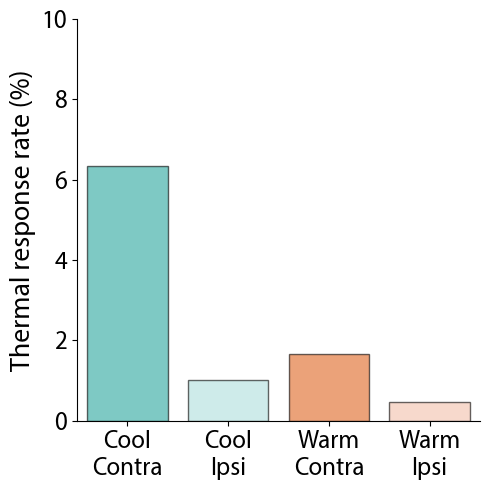


Métriques des réponses par groupe :
Cool_Cont : Moyenne = 0.06, Nombre de clusters = 504, Pourcentage de réponse = 6.3%
Cool_Ipsi : Moyenne = 0.01, Nombre de clusters = 296, Pourcentage de réponse = 1.0%
Warm_Cont : Moyenne = 0.02, Nombre de clusters = 422, Pourcentage de réponse = 1.7%
Warm_Ipsi : Moyenne = 0.00, Nombre de clusters = 210, Pourcentage de réponse = 0.5%


In [27]:
# Chemins fichiers
file_paths = {
    "Cool_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_WT_resp_rate.xlsx",
    "Cool_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wipsi_WT_resp_rate.xlsx",
    "Warm_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_WT_resp_rate.xlsx",
    "Warm_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wipsi_WT_resp_rate.xlsx"
}

# Chargement des données
dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")


# Calcul pourcentages réponse/non-réponse
group_counts = {}
for key, df in dfs.items():
    counts = df['response'].value_counts(normalize=True) * 100
    group_counts[key] = {
        'No Response (0)': counts.get(0, 0),
        'Response (1)': counts.get(1, 0)
    }


# DataFrame pour plot
contingency_df = pd.DataFrame(group_counts).T.reset_index().rename(columns={'index': 'group'})
contingency_melted = contingency_df.melt(id_vars='group', var_name='Response Type', value_name='Percentage')
contingency_melted_response_only = contingency_melted[contingency_melted['Response Type'] == 'Response (1)']


# Couleurs personnalisées
response_colors = {
    'Cool_Cont': '#13bbaf', 'Cool_Ipsi': '#A6E7E3',
    'Warm_Cont': '#ff5b00', 'Warm_Ipsi': '#FFBC9E'
}
border_colors = ['black'] * 4  # Épaisseur des bords

# Plot barplot
plt.figure(figsize=(5, 5))
ax = sns.barplot(
    data=contingency_melted_response_only,
    x='group', y='Percentage', hue='group',
    palette=response_colors,
    edgecolor=border_colors,
    alpha=0.6, errorbar=None
)

# Table de contingence brute
contingency_table = pd.DataFrame({
    key: dfs[key]['response'].value_counts() for key in dfs.keys()
}).fillna(0).astype(int).T

print("\nTable de contingence (nombre d'occurences de 0 et 1 par groupe) :")
print(contingency_table)

# Test global chi2
chi2, p, dof, expected = chi2_contingency(contingency_table.values)
print(f"\nTest chi2 de contingence entre groupes : chi2 = {chi2:.3f}, p = {p:.4g}, dof = {dof}")
if p < 0.05:
    print("=> Différence significative entre groupes")
else:
    print("=> Pas de différence significative entre groupes")

# Tests post-hoc (Fisher exact test)
groups = contingency_table.index.tolist()
results = []

for g1, g2 in combinations(groups, 2):
    table = contingency_table.loc[[g1, g2], [0, 1]].values
    oddsratio, pvalue = fisher_exact(table)
    results.append({'Group1': g1, 'Group2': g2, 'pvalue': pvalue})

# Correction Bonferroni
num_tests = len(results)
for res in results:
    res['pvalue_corrected'] = min(res['pvalue'] * num_tests, 1.0)

print("\nTests post-hoc (test exact de Fisher) avec correction de Bonferroni :")
for res in results:
    signif = "SIGNIFICATIF" if res['pvalue_corrected'] < 0.05 else "non significatif"
    print(f"{res['Group1']} vs {res['Group2']} : p = {res['pvalue']:.4g}, p corrigé = {res['pvalue_corrected']:.4g} -> {signif}")


# # Annoter les significativités sur le plot
# def add_contingence_sig_bar(ax, x1, x2, y, p_val, height_offset=0.15, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     if significance:
#         ax.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         ax.text((x1 + x2) * 0.5, y - 0.05 , significance,
#                 ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {g: i for i, g in enumerate(contingency_df['group'])}
# y_offset = contingency_melted_response_only['Percentage'].max() + 0.5
# spacing_between_bars = 0.8

# for res in results:
#     if res['pvalue_corrected'] < 0.05:
#         x1 = positions[res['Group1']]
#         x2 = positions[res['Group2']]
#         add_contingence_sig_bar(ax, x1, x2, y_offset, res['pvalue_corrected'])
#         y_offset += spacing_between_bars

# Labels
plt.xlabel('')
plt.ylabel('Thermal response rate (%)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
plt.yticks(range(0, 11, 2))
plt.ylim(0, 10)

# Suppression bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend().remove()
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2F_BIS_WT_cool_warm_cont_ipsi_resp_rate_cluster_contingence.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2F_BIS_WT_cool_warm_cont_ipsi_resp_rate_cluster_contingence.svg'), format='svg', dpi=300)

plt.show()


############################ Metrics ############################

print("\nMétriques des réponses par groupe :")
for key, df in dfs.items():
    mean_response = df['response'].mean()  # moyenne des 0 et 1 = taux de réponse en fraction
    n_clusters = len(df)
    response_percentage = mean_response * 100
    print(f"{key} : Moyenne = {mean_response:.2f}, Nombre de clusters = {n_clusters}, Pourcentage de réponse = {response_percentage:.1f}%")



#

### Fig 2.G - WT Thermic cool & warm - contra & ipsi sdf for TS

Directories communs à toutes les conditions : {'2024.05.29', '2024.03.01', '2024.05.22', '2024.03.05', '2024.05.28_M2', '2024.05.28_M1', '2024.01.31', '2024.02.06'}


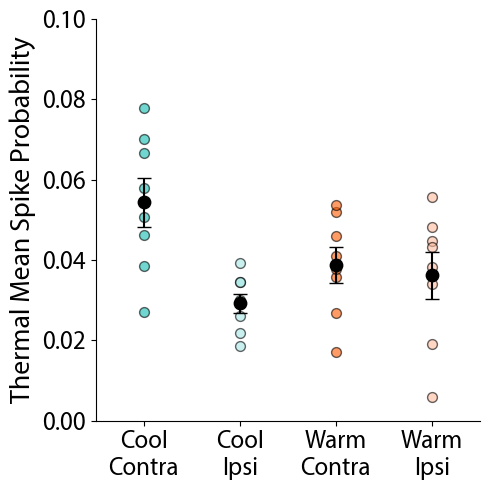

Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_2_WT_Thq\df_anova_sdf_wt_cool_warm_cont_ipsi.xlsx

Moyenne, SEM et nombre de points pour chaque groupe :
Groupe: Cool_Cont, Mean: 0.054340 ± SEM: 0.006042, N: 8
Groupe: Cool_Ipsi, Mean: 0.029216 ± SEM: 0.002440, N: 8
Groupe: Warm_Cont, Mean: 0.038742 ± SEM: 0.004397, N: 8
Groupe: Warm_Ipsi, Mean: 0.036151 ± SEM: 0.005785, N: 8

Cool_Cont: n_cluster : 289
Cool_Ipsi: n_cluster : 204
Warm_Cont: n_cluster : 287
Warm_Ipsi: n_cluster : 210

 ⚠️ Voir Graphpad pour Anova 2 way ⚠️


In [ ]:
# Charger les fichiers
WT_cool_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df_WT_cool_cont = pd.read_excel(WT_cool_cont_path)

WT_cool_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_WT_grouped.xlsx"
df_WT_cool_ipsi = pd.read_excel(WT_cool_ipsi_path)

WT_warm_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_WT_grouped.xlsx"
df_WT_warm_cont = pd.read_excel(WT_warm_cont_path)

WT_warm_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wipsi_WT_grouped.xlsx"
df_WT_warm_ipsi = pd.read_excel(WT_warm_ipsi_path)


# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_cool_cont_ts = df_WT_cool_cont[df_WT_cool_cont['period'] == 'Stim']
df_WT_cool_ipsi_ts = df_WT_cool_ipsi[df_WT_cool_ipsi['period'] == 'Stim']
df_WT_warm_cont_ts = df_WT_warm_cont[df_WT_warm_cont['period'] == 'Stim']
df_WT_warm_ipsi_ts = df_WT_warm_ipsi[df_WT_warm_ipsi['period'] == 'Stim']


# Trouver les 'directory' communs à toutes les conditions
common_directories = set.intersection(
    *(set(df['directory']) for df in [df_WT_cool_cont_ts, df_WT_cool_ipsi_ts, df_WT_warm_cont_ts, df_WT_warm_ipsi_ts])
)

print("Directories communs à toutes les conditions :", common_directories)

# Filtrer les DataFrames pour ne conserver que les 'directory' communs
df_WT_cool_cont_ts_filtered = df_WT_cool_cont_ts[df_WT_cool_cont_ts['directory'].isin(common_directories)]
df_WT_cool_ipsi_ts_filtered = df_WT_cool_ipsi_ts[df_WT_cool_ipsi_ts['directory'].isin(common_directories)]
df_WT_warm_cont_ts_filtered = df_WT_warm_cont_ts[df_WT_warm_cont_ts['directory'].isin(common_directories)]
df_WT_warm_ipsi_ts_filtered = df_WT_warm_ipsi_ts[df_WT_warm_ipsi_ts['directory'].isin(common_directories)]


# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_WT_cool_cont_ts_filtered_animal = df_WT_cool_cont_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
df_WT_cool_ipsi_ts_filtered_animal = df_WT_cool_ipsi_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
df_WT_warm_cont_ts_filtered_animal = df_WT_warm_cont_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
df_WT_warm_ipsi_ts_filtered_animal = df_WT_warm_ipsi_ts_filtered.groupby('directory')['sdf'].mean().reset_index()


# Ajouter une colonne pour différencier les groupes
df_WT_cool_cont_ts_filtered_animal['group'] = 'Cool_Cont'
df_WT_cool_ipsi_ts_filtered_animal['group'] = 'Cool_Ipsi' 
df_WT_warm_cont_ts_filtered_animal['group'] = 'Warm_Cont' 
df_WT_warm_ipsi_ts_filtered_animal['group'] = 'Warm_Ipsi' 


# Fusionner les données pour analyse statistique
df_merged = pd.concat([df_WT_cool_cont_ts_filtered_animal, df_WT_cool_ipsi_ts_filtered_animal, df_WT_warm_cont_ts_filtered_animal, df_WT_warm_ipsi_ts_filtered_animal])

# Fusionner pour le tracé
df_combined = pd.concat([df_WT_cool_cont_ts_filtered_animal, df_WT_cool_ipsi_ts_filtered_animal, df_WT_warm_cont_ts_filtered_animal, df_WT_warm_ipsi_ts_filtered_animal])

# Couleurs des groupes
colors = {'Cool_Cont': '#13bbaf', 'Cool_Ipsi': '#A6E7E3', 
          'Warm_Cont': '#ff5b00', 'Warm_Ipsi': '#FFBC9E'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(5, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['Cool_Cont','Cool_Ipsi', 'Warm_Cont', 'Warm_Ipsi']:
    subset = df_combined[df_combined['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)

# Calcul des moyennes et SEM
mean_sdf = df_combined.groupby('group')['sdf'].mean()
sem_sdf = df_combined.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Thermal Mean Spike Probability")
plt.xticks(range(4), ['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
plt.xlim(-0.5, 3.5)
plt.ylim(0, 0.1)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2G_WT_cool_warm_cont_ipsi_SDF.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2G_WT_cool_warm_cont_ipsi_SDF.svg'), format='svg', dpi=300)


plt.show()


file_name = "df_anova_sdf_wt_cool_warm_cont_ipsi.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
df_combined.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################ Metrics ############################

# Afficher les résultats avec le nombre de points pour chaque groupe
print("\nMoyenne, SEM et nombre de points pour chaque groupe :")
for group in ['Cool_Cont', 'Cool_Ipsi', 'Warm_Cont', 'Warm_Ipsi']:
    # Calcul de la moyenne et de l'écart-type
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    # Calcul du nombre de points dans chaque groupe
    n_points = len(df_combined[df_combined['group'] == group])
    # Affichage du groupe, de la moyenne, de l'écart-type et du nombre de points
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}, N: {n_points}")


# Calculer nombre de clusters par condition
n_cluster_cool_cont = len(df_WT_cool_cont_ts_filtered)
n_cluster_cool_ipsi = len(df_WT_cool_ipsi_ts_filtered)
n_cluster_warm_cont = len(df_WT_warm_cont_ts_filtered)
n_cluster_warm_ipsi = len(df_WT_warm_ipsi_ts_filtered)


print(f"\nCool_Cont: n_cluster : {n_cluster_cool_cont}")
print(f"Cool_Ipsi: n_cluster : {n_cluster_cool_ipsi}")
print(f"Warm_Cont: n_cluster : {n_cluster_warm_cont}")
print(f"Warm_Ipsi: n_cluster : {n_cluster_warm_ipsi}")

print (f'\n ⚠️ Voir Graphpad pour Anova 2 way ⚠️')


plt.text(0.5, 0.5, '⚠️ Voir Graphpad pour Anova 2 way ⚠️', fontsize=16, ha='center')
plt.axis('off')
plt.show()


#

### Fig 2.G_BIS - Clusters - WT Thermic cool & warm - contra & ipsi sdf for TS

Directories communs à toutes les conditions : {'2024.03.01', '2024.01.31', '2024.05.29', '2024.05.28_M2', '2024.02.06', '2024.05.28_M1', '2024.05.22', '2024.03.05'}


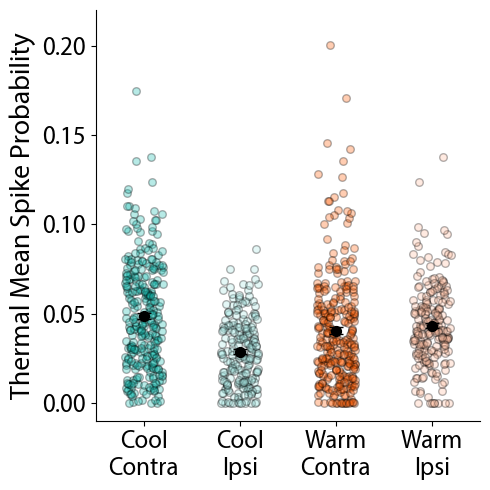

Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_2_WT_Thq\df_anova_sdf_wt_cool_warm_cont_ipsi_cluster.xlsx

Moyenne, SEM et nombre de points pour chaque groupe :
Groupe: Cool_Cont, Mean: 0.048633 ± SEM: 0.001791, n: 289
Groupe: Warm_Cont, Mean: 0.040334 ± SEM: 0.001880, n: 287
Groupe: Cool_Ipsi, Mean: 0.028656 ± SEM: 0.001349, n: 204
Groupe: Warm_Ipsi, Mean: 0.043200 ± SEM: 0.001568, n: 210

 ⚠️ Voir Stat sur Graphpad avec Mixed-effects Model (REML) with Bonferroni multiple comparisons test ⚠️


In [5]:
# Charger les fichiers
WT_cool_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df_WT_cool_cont = pd.read_excel(WT_cool_cont_path)

WT_warm_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_WT_grouped.xlsx"
df_WT_warm_cont = pd.read_excel(WT_warm_cont_path)

WT_cool_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_WT_grouped.xlsx"
df_WT_cool_ipsi = pd.read_excel(WT_cool_ipsi_path)

WT_warm_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wipsi_WT_grouped.xlsx"
df_WT_warm_ipsi = pd.read_excel(WT_warm_ipsi_path)


# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_cool_cont_ts = df_WT_cool_cont[df_WT_cool_cont['period'] == 'Stim']
df_WT_warm_cont_ts = df_WT_warm_cont[df_WT_warm_cont['period'] == 'Stim']
df_WT_cool_ipsi_ts = df_WT_cool_ipsi[df_WT_cool_ipsi['period'] == 'Stim']
df_WT_warm_ipsi_ts = df_WT_warm_ipsi[df_WT_warm_ipsi['period'] == 'Stim']


# Trouver les 'directory' communs à toutes les conditions
common_directories = set.intersection(
    *(set(df['directory']) for df in [df_WT_cool_cont_ts, df_WT_warm_cont_ts, df_WT_cool_ipsi_ts, df_WT_warm_ipsi_ts])
)

print("Directories communs à toutes les conditions :", common_directories)

# Filtrer les DataFrames pour ne conserver que les 'directory' communs
df_WT_cool_cont_ts_filtered = df_WT_cool_cont_ts[df_WT_cool_cont_ts['directory'].isin(common_directories)]
df_WT_warm_cont_ts_filtered = df_WT_warm_cont_ts[df_WT_warm_cont_ts['directory'].isin(common_directories)]
df_WT_cool_ipsi_ts_filtered = df_WT_cool_ipsi_ts[df_WT_cool_ipsi_ts['directory'].isin(common_directories)]
df_WT_warm_ipsi_ts_filtered = df_WT_warm_ipsi_ts[df_WT_warm_ipsi_ts['directory'].isin(common_directories)]


# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_WT_cool_cont_ts_filtered_cluster = df_WT_cool_cont_ts_filtered.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_WT_warm_cont_ts_filtered_cluster = df_WT_warm_cont_ts_filtered.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_WT_cool_ipsi_ts_filtered_cluster = df_WT_cool_ipsi_ts_filtered.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_WT_warm_ipsi_ts_filtered_cluster = df_WT_warm_ipsi_ts_filtered.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)


# Ajouter une colonne pour différencier les groupes
df_WT_cool_cont_ts_filtered_cluster['group'] = 'Cool_Cont'
df_WT_warm_cont_ts_filtered_cluster['group'] = 'Warm_Cont' 
df_WT_cool_ipsi_ts_filtered_cluster['group'] = 'Cool_Ipsi' 
df_WT_warm_ipsi_ts_filtered_cluster['group'] = 'Warm_Ipsi' 


# Fusionner pour le tracé
df_combined_cluster = pd.concat([df_WT_cool_cont_ts_filtered_cluster, df_WT_warm_cont_ts_filtered_cluster, df_WT_cool_ipsi_ts_filtered_cluster, 
                             df_WT_warm_ipsi_ts_filtered_cluster])

# Couleurs
colors = {'Cool_Cont': '#13bbaf', 'Cool_Ipsi': '#A6E7E3', 
          'Warm_Cont': '#ff5b00', 'Warm_Ipsi': '#FFBC9E'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(5, 5))

# Ajouter les points individuels avec léger jitter
group_mapping = {'Cool_Cont': 0, 'Cool_Ipsi': 1, 'Warm_Cont': 2, 'Warm_Ipsi': 3}
for group in ['Cool_Cont', 'Cool_Ipsi', 'Warm_Cont', 'Warm_Ipsi']:
    subset = df_combined_cluster[df_combined_cluster['group'] == group]
    x_vals = np.ones(len(subset)) * group_mapping[group]
    x_vals += np.random.uniform(-0.2, 0.2, size=len(subset))  # jitter horizontal
    plt.scatter(x_vals, subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.3, s=30, zorder=6)

# Calcul des moyennes et SEM
mean_sdf_cluster = df_combined_cluster.groupby('group')['sdf'].mean()
sem_sdf_cluster = df_combined_cluster.groupby('group')['sdf'].sem()


# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf_cluster.index, mean_sdf_cluster.values, color='black', s=50, label='Mean', zorder=10)
plt.errorbar(mean_sdf_cluster.index, mean_sdf_cluster.values, yerr=sem_sdf_cluster.values, fmt='o', color='black', capsize=5, zorder=8)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Thermal Mean Spike Probability")
plt.xticks(range(4), ['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
plt.xlim(-0.5, 3.5)
plt.ylim(-0.01, 0.22)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2G_BIS_WT_cool_warm_cont_ipsi_SDF_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2G_BIS_WT_cool_warm_cont_ipsi_SDF_cluster.svg'), format='svg', dpi=300)


plt.show()


file_name = "df_anova_sdf_wt_cool_warm_cont_ipsi_cluster.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
df_combined_cluster.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################ Metrics ############################

# Afficher les résultats avec le nombre de points pour chaque groupe
print("\nMoyenne, SEM et nombre de points pour chaque groupe :")
for group in ['Cool_Cont', 'Warm_Cont', 'Cool_Ipsi', 'Warm_Ipsi']:
    # Calcul de la moyenne et de l'écart-type
    mean = mean_sdf_cluster[group]
    sem = sem_sdf_cluster[group]
    # Calcul du nombre de points dans chaque groupe
    n_points = len(df_combined_cluster[df_combined_cluster['group'] == group])
    # Affichage du groupe, de la moyenne, de l'écart-type et du nombre de points
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}, n: {n_points}")


print (f'\n ⚠️ Voir Stat sur Graphpad avec Mixed-effects Model (REML) with Bonferroni multiple comparisons test ⚠️')


# from rich import print
# print("[bold green]⚠️ Voir Graphpad pour Anova 2 way ⚠️[/bold green]")




#

### Fig 2.H - SDF_mean Thermic cool contra WT

Friedman test results:
          Source     W  ddof1    Q     p-unc
Friedman  period  0.49      2  9.8  0.007447
Effet global de period: Significatif (p-unc = 0.0074)

Post-hoc Dunn test with Bonferroni correction:
           Baseline      Stim  Post_stim
Baseline   1.000000  0.111808   0.487239
Stim       0.111808  1.000000   0.001505
Post_stim  0.487239  0.001505   1.000000


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


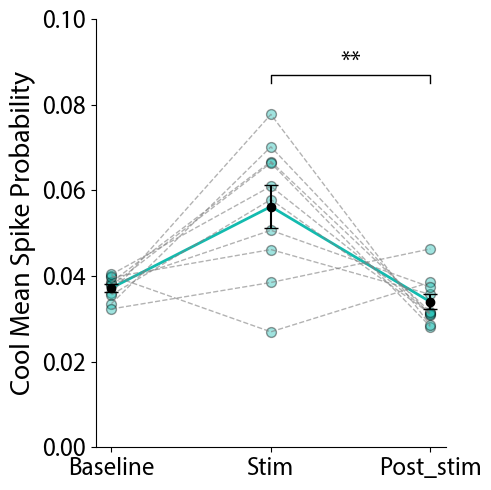

Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_2_WT_Thq\df_anova_sdf_wt_cool__cont_ipsi.xlsx
      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.037196  0.000873        10
1       Stim  0.056204  0.004942        10
2  Post_stim  0.033963  0.001768        10

       period  n_cluster
0   Baseline        504
1  Post_stim        504
2       Stim        504


In [4]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#13bbaf'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.085  # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2H_SDF_WT_Cool_contra_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2H_SDF_WT_Cool_contra_period.svg'), format='svg', dpi=300)

plt.show()



file_name = "df_anova_sdf_wt_cool__cont_ipsi.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
df_grouped.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


##### Moyenage par directory et file_name

Friedman test results:
          Source     W  ddof1    Q     p-unc
Friedman  period  0.49      2  9.8  0.007447
Effet global de period: Significatif (p-unc = 0.0074)

Post-hoc Dunn test with Bonferroni correction:
           Baseline      Stim  Post_stim
Baseline   1.000000  0.111808    0.42209
Stim       0.111808  1.000000    0.00113
Post_stim  0.422090  0.001130    1.00000


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


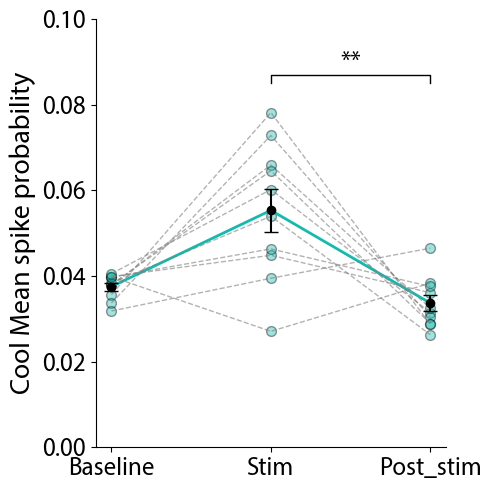

      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.037522  0.000919        10
1       Stim  0.055329  0.005046        10
2  Post_stim  0.033668  0.001903        10

       period  n_cluster
0   Baseline        504
1  Post_stim        504
2       Stim        504


In [7]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']


# Calculer la moyenne de 'sdf' pour chaque combinaison 'directory' + 'file_name' + 'period'
df_grouped_animal_rec = df.groupby(['directory', 'file_name', 'period'], observed=False)['sdf'].mean().reset_index()

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped_animal = df_grouped_animal_rec.groupby(['directory','period'])['sdf'].mean().reset_index()


# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped_animal['period'] = pd.Categorical(df_grouped_animal['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped_animal = df_grouped_animal.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped_animal.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped_animal.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped_animal, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped_animal, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#13bbaf'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped_animal['period'], df_grouped_animal['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped_animal['directory'].unique():
    subset = df_grouped_animal[df_grouped_animal['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.085  # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Cool Mean spike probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()



plt.show()



# file_name = "df_anova_sdf_wt_cool__cont_ipsi.xlsx"

# anova_path = os.path.join(saving_dir,file_name)

# # Sauvegarder le DataFrame `df_combined` dans le fichier Excel
# df_grouped.to_excel(anova_path , index=False)

# print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################    Metrics   ############################ 

summary_table = df_grouped_animal.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


#### Filtrage des données avec seulement les animaux qui reponsent en cool

Friedman test results:
          Source    W  ddof1     Q     p-unc
Friedman  period  1.0      2  12.0  0.002479
Effet global de period: Significatif (p-unc = 0.0025)

Post-hoc Dunn test with Bonferroni correction:
           Baseline      Stim  Post_stim
Baseline   1.000000  0.104865   0.314272
Stim       0.104865  1.000000   0.000572
Post_stim  0.314272  0.000572   1.000000


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


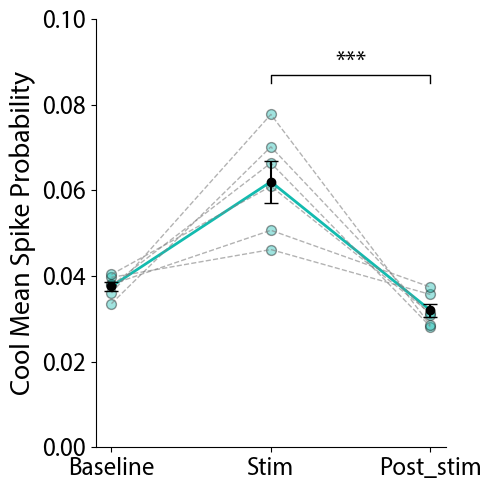

      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.037570  0.001017         6
1       Stim  0.062007  0.004876         6
2  Post_stim  0.031997  0.001542         6

       period  n_cluster
0   Baseline        390
1  Post_stim        390
2       Stim        390


In [5]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files_filtered_shank_thq_cool/Thq-cool_Wcont_WT_sdf_mean_period_filtered.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#13bbaf'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.085  # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# # Sauvegarder la figure
# plt.savefig(os.path.join(saving_dir, '2Hbis_SDF_WT_Cool_contra_period.png'), format='png', dpi=300)
# plt.savefig(os.path.join(saving_dir, '2Hbis_SDF_WT_Cool_contra_period.svg'), format='svg', dpi=300)

plt.show()



# file_name = "df_anova_sdf_wt_cool__cont_ipsi.xlsx"

# anova_path = os.path.join(saving_dir,file_name)

# # Sauvegarder le DataFrame `df_combined` dans le fichier Excel
# df_grouped.to_excel(anova_path , index=False)

# print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


#

### Fig 2.H_BIS - Clusters - SDF_mean Thermic cool contra WT

Period Baseline: p = 0.3131 (Normal)
Period Stim: p = 0.0002 (Non normal)
Period Post_stim: p = 0.1896 (Normal)

📊 Résultats du test de Friedman :
          Source         W  ddof1           Q         p-unc
Friedman  period  0.137027      2  138.123016  1.016174e-30

Effet global de 'period' : Significatif (p = 0.0000)

🧪 Post-hoc Dunn avec correction Bonferroni :
               Baseline          Stim     Post_stim
Baseline   1.000000e+00  6.494207e-22  2.045045e-07
Stim       6.494207e-22  1.000000e+00  3.095954e-51
Post_stim  2.045045e-07  3.095954e-51  1.000000e+00


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


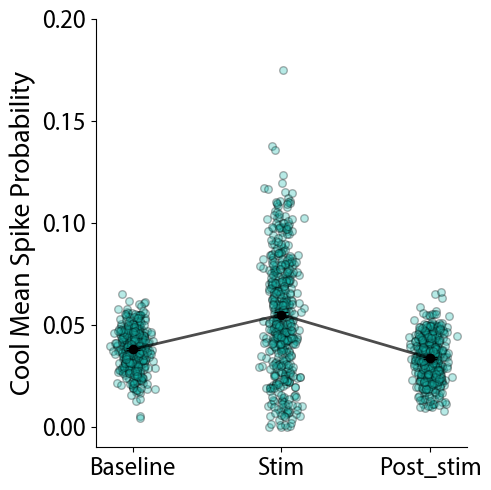


📈 Tableau récapitulatif par période :
      period  mean_sdf   sem_sdf  N_neuron_unique
0   Baseline  0.038056  0.000418              504
1       Stim  0.055018  0.001271              504
2  Post_stim  0.033645  0.000463              504


In [28]:
from scipy.stats import shapiro


#  Charger le fichier Excel
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']
df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_unique = df.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Calculer la moyenne et SEM globales par période
mean_sem = df_unique.groupby('period', observed=True)['sdf'].agg(['mean', 'sem']).reindex(period_order)

# 1. Nettoyage des données
df_unique_clean = df_unique.dropna(subset=['sdf'])

# 2. Créer une colonne 'subject' pour identifier chaque neurone
df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)


for period in df_unique_clean['period'].unique():
    subset = df_unique_clean[df_unique_clean['period'] == period]
    stat, p = shapiro(subset['sdf'])
    print(f"Period {period}: p = {p:.4f} ({'Non normal' if p < 0.05 else 'Normal'})")


# ---------- 📊 TEST DE FRIEDMAN ----------
# # 1. Nettoyage des données
# df_unique_clean = df_unique.dropna(subset=['sdf'])

# # 2. Créer une colonne 'subject' pour identifier chaque neurone
# df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)

# 3. S'assurer que les périodes sont bien catégorisées et ordonnées
period_order = ['Baseline', 'Stim', 'Post_stim']
df_unique_clean['period'] = pd.Categorical(df_unique_clean['period'], categories=period_order, ordered=True)

# 4. Garder seulement les sujets ayant des valeurs pour toutes les périodes (Friedman exige mesures répétées complètes)
complete_subjects = df_unique_clean.groupby('subject')['period'].nunique() == len(period_order)
df_friedman_cool_cluster = df_unique_clean[df_unique_clean['subject'].isin(complete_subjects[complete_subjects].index)]

# 5. Appliquer le test de Friedman (format long)
friedman_results_cool_cluster = pg.friedman(data=df_friedman_cool_cluster, dv='sdf', within='period', subject='subject')
print("\n📊 Résultats du test de Friedman :")
print(friedman_results_cool_cluster)

# 6. Vérifier significativité
pval_cool_cluster = friedman_results_cool_cluster['p-unc'].iloc[0]
effect_significance = "Significatif" if pval_cool_cluster < 0.05 else "Non significatif"
print(f"\nEffet global de 'period' : {effect_significance} (p = {pval_cool_cluster:.4f})")

# 7. Si significatif, faire un post-hoc de Dunn
if pval_cool_cluster < 0.05:
    print("\n🧪 Post-hoc Dunn avec correction Bonferroni :")
    posthoc_results_cool_cluster = sp.posthoc_dunn(df_friedman_cool_cluster, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results_cool_cluster = posthoc_results_cool_cluster.loc[period_order, period_order]
    print(posthoc_results_cool_cluster)


# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#13bbaf'
border_colors = 'k'

# Appliquer un jitter sur l'axe x
x_jitter = df_unique['period'].cat.codes + np.random.normal(0, 0.05, size=len(df_unique))

# Puis plot avec jitter
plt.scatter(x_jitter, df_unique['sdf'],
            color=colors, edgecolor=border_colors,
            linewidth=1, alpha=0.3, marker='o', s=30, zorder=0)

# Ajouter les moyennes ± SEM
plt.errorbar(mean_sem.index, mean_sem['mean'], yerr=mean_sem['sem'],
             fmt='o', color='black', capsize=5, label='Mean ± SEM', zorder=2)
plt.plot(mean_sem.index, mean_sem['mean'],
         color='k', alpha=0.7, linestyle='-', linewidth=2, zorder=1)

# # Ajouter les barres de significativité
# def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
    
#     if significance:
#         plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
# y_offset = 0.15  # Décalage vertical initial
# spacing_between_bars = 0.015

# if friedman_results_cool_cluster['p-unc'].iloc[0] < 0.05 :
#     for i, p1 in enumerate(period_order):
#         for j, p2 in enumerate(period_order):
#             if i < j:
#                 p_val = posthoc_results_cool_cluster.loc[p1, p2]
#                 if p_val < 0.05:
#                     add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
#                     y_offset += spacing_between_bars



plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(-0.01,0.2)
plt.xlim(-0.25, len(period_order) - 0.75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2H_BIS_SDF_WT_Cool_contra_period_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2H_BIS_SDF_WT_Cool_contra_period_cluster.svg'), format='svg', dpi=300)

plt.show()


############################    📊 Résumé par période   ############################

summary_table = df_friedman_cool_cluster.groupby('period', observed=True).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_neuron_unique=('subject', 'nunique')
).reset_index()

print("\n📈 Tableau récapitulatif par période :")
print(summary_table)


#

### Fig 2.I - SDF_mean Thermic Warm contra WT

Friedman test results:
          Source     W  ddof1    Q     p-unc
Friedman  period  0.13      2  2.6  0.272532
Effet global de period: Non significatif (p-unc = 0.2725)


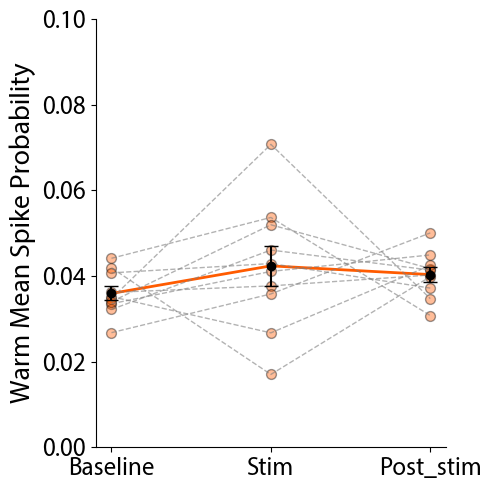

Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_2_WT_Thq\df_anova_sdf_wt_warm_period.xlsx
      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.035926  0.001618        10
1       Stim  0.042356  0.004705        10
2  Post_stim  0.040323  0.001688        10

       period  n_cluster
0   Baseline        422
1  Post_stim        422
2       Stim        422


In [26]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#ff5b00'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=16):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.09 # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Warm Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2I_SDF_WT_Warm_contra_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2I_SDF_WT_Warm_contra_period.svg'), format='svg', dpi=300)

plt.show()


file_name = "df_anova_sdf_wt_warm_period.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
df_grouped.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")



############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


#### Filtrage des données avec seulement les animaux qui reponsent en warm

Friedman test results:
          Source         W  ddof1    Q     p-unc
Friedman  period  0.333333      2  2.0  0.367879
Effet global de period: Non significatif (p-unc = 0.3679)


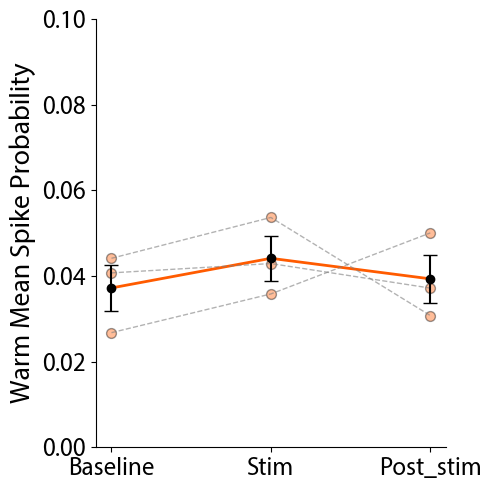

      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.037202  0.005311         3
1       Stim  0.044123  0.005191         3
2  Post_stim  0.039329  0.005673         3

       period  n_cluster
0   Baseline        179
1  Post_stim        179
2       Stim        179


In [8]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files_filtered_shank_thq_hot/Thq-hot_Wcont_WT_sdf_mean_period_warm_animal_filtered.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#ff5b00'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=16):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.09 # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Warm Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# # Sauvegarder la figure
# plt.savefig(os.path.join(saving_dir, '2Ibis_SDF_WT_Warm_contra_period.png'), format='png', dpi=300)
# plt.savefig(os.path.join(saving_dir, '2Ibis_SDF_WT_Warm_contra_period.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


### Fig 2.I_BIS - Clusters - SDF_mean Thermic Warm contra WT

Period Baseline: p = 0.1423 (Normal)
Period Stim: p = 0.0000 (Non normal)
Period Post_stim: p = 0.6775 (Normal)

📊 Résultats du test de Friedman :
          Source       W  ddof1         Q     p-unc
Friedman  period  0.0026      2  2.194313  0.333819

Effet global de 'period' : Non significatif (p = 0.3338)


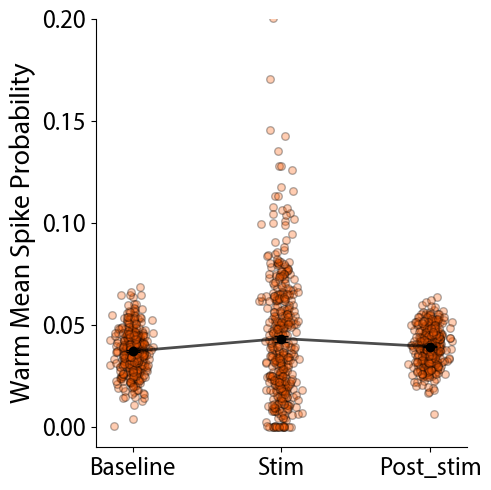


📈 Tableau récapitulatif par période :
      period  mean_sdf   sem_sdf  N_neuron_unique
0   Baseline  0.037159  0.000499              422
1       Stim  0.043330  0.001464              422
2  Post_stim  0.039370  0.000430              422


In [29]:
from scipy.stats import shapiro


#  Charger le fichier Excel
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']
df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_unique = df.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Calculer la moyenne et SEM globales par période
mean_sem = df_unique.groupby('period', observed=True)['sdf'].agg(['mean', 'sem']).reindex(period_order)

# 1. Nettoyage des données
df_unique_clean = df_unique.dropna(subset=['sdf'])

# 2. Créer une colonne 'subject' pour identifier chaque neurone
df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)


for period in df_unique_clean['period'].unique():
    subset = df_unique_clean[df_unique_clean['period'] == period]
    stat, p = shapiro(subset['sdf'])
    print(f"Period {period}: p = {p:.4f} ({'Non normal' if p < 0.05 else 'Normal'})")


# ---------- 📊 TEST DE FRIEDMAN ----------
# # 1. Nettoyage des données
# df_unique_clean = df_unique.dropna(subset=['sdf'])

# # 2. Créer une colonne 'subject' pour identifier chaque neurone
# df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)

# 3. S'assurer que les périodes sont bien catégorisées et ordonnées
period_order = ['Baseline', 'Stim', 'Post_stim']
df_unique_clean['period'] = pd.Categorical(df_unique_clean['period'], categories=period_order, ordered=True)

# 4. Garder seulement les sujets ayant des valeurs pour toutes les périodes (Friedman exige mesures répétées complètes)
complete_subjects = df_unique_clean.groupby('subject')['period'].nunique() == len(period_order)
df_friedman_warm_cluster = df_unique_clean[df_unique_clean['subject'].isin(complete_subjects[complete_subjects].index)]

# 5. Appliquer le test de Friedman (format long)
friedman_results_warm_cluster = pg.friedman(data=df_friedman_warm_cluster, dv='sdf', within='period', subject='subject')
print("\n📊 Résultats du test de Friedman :")
print(friedman_results_warm_cluster)

# 6. Vérifier significativité
pval_warm_cluster = friedman_results_warm_cluster['p-unc'].iloc[0]
effect_significance = "Significatif" if pval_warm_cluster < 0.05 else "Non significatif"
print(f"\nEffet global de 'period' : {effect_significance} (p = {pval_warm_cluster:.4f})")

# 7. Si significatif, faire un post-hoc de Dunn
if pval_warm_cluster < 0.05:
    print("\n🧪 Post-hoc Dunn avec correction Bonferroni :")
    posthoc_results_warm_cluster = sp.posthoc_dunn(df_friedman_warm_cluster, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results_warm_cluster = posthoc_results_warm_cluster.loc[period_order, period_order]
    print(posthoc_results_warm_cluster)


# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#ff5b00'
border_colors = 'k'

# Appliquer un jitter sur l'axe x
x_jitter = df_unique['period'].cat.codes + np.random.normal(0, 0.05, size=len(df_unique))

# Puis plot avec jitter
plt.scatter(x_jitter, df_unique['sdf'],
            color=colors, edgecolor=border_colors,
            linewidth=1, alpha=0.3, marker='o', s=30, zorder=0)

# Ajouter les moyennes ± SEM
plt.errorbar(mean_sem.index, mean_sem['mean'], yerr=mean_sem['sem'],
             fmt='o', color='black', capsize=5, label='Mean ± SEM', zorder=2)
plt.plot(mean_sem.index, mean_sem['mean'],
         color='k', alpha=0.7, linestyle='-', linewidth=2, zorder=1)

# # Ajouter les barres de significativité
# def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
    
#     if significance:
#         plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
# y_offset = 0.15  # Décalage vertical initial
# spacing_between_bars = 0.015

# if friedman_results_warm_cluster['p-unc'].iloc[0] < 0.05 :
#     for i, p1 in enumerate(period_order):
#         for j, p2 in enumerate(period_order):
#             if i < j:
#                 p_val = posthoc_results_warm_cluster.loc[p1, p2]
#                 if p_val < 0.05:
#                     add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
#                     y_offset += spacing_between_bars



plt.xlabel("")
plt.ylabel("Warm Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(-0.01,0.2)
plt.xlim(-0.25, len(period_order) - 0.75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '2I_bis_SDF_WT_Warm_contra_period_clusters.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '2I_bis_SDF_WT_Warm_contra_period_clusters.svg'), format='svg', dpi=300)

plt.show()


############################    📊 Résumé par période   ############################

summary_table = df_friedman_warm_cluster.groupby('period', observed=True).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_neuron_unique=('subject', 'nunique')
).reset_index()

print("\n📈 Tableau récapitulatif par période :")
print(summary_table)


#

# SDF Analysis by age

c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


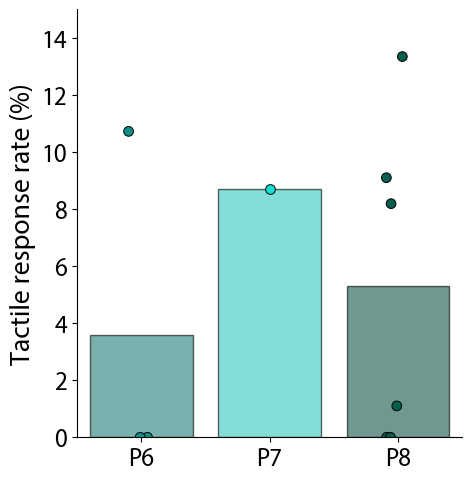

Kruskal-Wallis test: H = 0.523, p = 0.7701


C:\Users\zayan\AppData\Local\Temp\ipykernel_29276\3582735131.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = response_percentage.groupby('age')['response']


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem
from scipy.stats import kruskal


# Charger les données contra uniquement
WT_cool_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_WT_resp_rate.xlsx"
df_WT_cool_cont = pd.read_excel(WT_cool_cont_path)

# Calcul du pourcentage de réponse pour chaque directory
response_percentage = df_WT_cool_cont.groupby(['directory'])['response'].agg(
    lambda x: (x.sum() / len(x)) * 100
).reset_index()

# Ajouter l'âge depuis 'file_name' ou directement depuis df_WT_cool_cont
file_age_map = df_WT_cool_cont[['directory', 'age']].drop_duplicates()
response_percentage = response_percentage.merge(file_age_map, on='directory', how='left')

# Définir l'ordre des âges correct : P6, P7, P8
age_order = ['P6', 'P7', 'P8']
response_percentage['age'] = pd.Categorical(response_percentage['age'], categories=age_order, ordered=True)

# Calcul des moyennes et SEM par âge
mean_sem_by_age = response_percentage.groupby('age', observed=True)['response'].agg(['mean', sem]).reset_index()
mean_sem_by_age.rename(columns={'mean': 'response_mean', 'sem': 'response_sem'}, inplace=True)

# Couleurs personnalisées (modifiable à ton goût)
age_colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}


# Création de la figure
plt.figure(figsize=(5, 5))

# Barplot (moyenne ± SEM)
sns.barplot(
    data=mean_sem_by_age, x='age', y='response_mean', hue='age',
    palette=age_colors, capsize=0.2, edgecolor='k', alpha=0.6,
    err_kws={'color': 'k', 'linewidth': 1.5},
    legend=False
)


# Ajouter les points individuels par directory
sns.stripplot(
    data=response_percentage, x='age', y='response', hue='age',
    palette=age_colors, s=7, jitter=True, dodge=False,
    edgecolor='k', linewidth=0.7,
    legend=False
)


# Personnalisation
plt.ylabel("Tactile response rate (%)")
plt.xlabel("")
plt.ylim(0, 15)

# Nettoyage des bordures
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Age_response_rate_WT_thq_cool.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Age_response_rate_WT_thq_cool.svg'), format='svg', dpi=300)

plt.show()



################# Stat Kruskal-Wallis #################

# Extraire les groupes de données pour chaque âge
grouped = response_percentage.groupby('age')['response']
P6_data = grouped.get_group('P6').dropna()
P7_data = grouped.get_group('P7').dropna()
P8_data = grouped.get_group('P8').dropna()

# Effectuer le test de Kruskal-Wallis
stat, p_value = kruskal(P6_data, P7_data, P8_data)

# Afficher le résultat
print(f"Kruskal-Wallis test: H = {stat:.3f}, p = {p_value:.4f}")


#

C:\Users\zayan\AppData\Local\Temp\ipykernel_1140\2199676426.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(['directory', 'period', 'age'])['sdf'].mean().reset_index()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


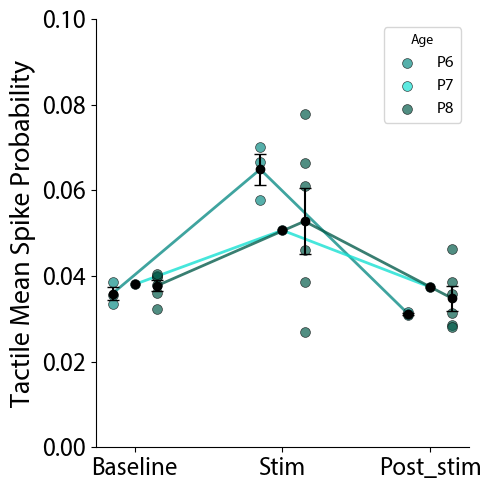


Résumé par période et âge :
      period age  mean_sdf   sem_sdf
0   Baseline  P6  0.035895  0.001452
1   Baseline  P7  0.038032       NaN
2   Baseline  P8  0.037706  0.001273
3       Stim  P6  0.064908  0.003668
4       Stim  P7  0.050670       NaN
5       Stim  P8  0.052775  0.007723
6  Post_stim  P6  0.031210  0.000218
7  Post_stim  P7  0.037413       NaN
8  Post_stim  P8  0.034765  0.002843

Nombre d'animaux uniques par âge :
P6 : 3
P7 : 1
P8 : 6


C:\Users\zayan\AppData\Local\Temp\ipykernel_1140\2199676426.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_animals_by_age = df[['directory', 'age']].drop_duplicates().groupby('age').size().to_dict()


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import scikit_posthocs as sp

# ------------------- CHARGEMENT DES DONNÉES ------------------- #

# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes et des âges
period_order = ['Baseline', 'Stim', 'Post_stim']
age_order = ['P6', 'P7', 'P8']

df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)
df['age'] = pd.Categorical(df['age'], categories=age_order, ordered=True)

# Calculer la moyenne de sdf par directory et period
df_grouped = df.groupby(['directory', 'period', 'age'])['sdf'].mean().reset_index()

# Moyenne + SEM par combinaison période-âge (pour le graph)
mean_sem_by_age = df_grouped.groupby(['period', 'age'], observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem')
).reset_index()

# ------------------- PLOT ------------------- #

# Définir les couleurs pour chaque âge
age_colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}

# Position x des périodes
period_positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
offset = 0.15  # pour espacer les âges

plt.figure(figsize=(5, 5))

# Tracer les points individuels avec décalage par âge
for i, period in enumerate(period_order):
    for j, age in enumerate(age_order):
        x = period_positions[period] + (j - 1) * offset  # -offset, 0, +offset
        subset = df_grouped[(df_grouped['period'] == period) & (df_grouped['age'] == age)]
        plt.scatter(
            [x] * len(subset),
            subset['sdf'],
            color=age_colors[age],
            edgecolor='k',
            linewidth=0.5,
            alpha=0.7,
            s=50,
            label=age if i == 0 else "",  # éviter doublons dans légende
            zorder=1
        )

# Ajouter les moyennes + SEM par période et âge
for i, period in enumerate(period_order):
    for j, age in enumerate(age_order):
        x = period_positions[period] + (j - 1) * offset
        row = mean_sem_by_age[(mean_sem_by_age['period'] == period) & (mean_sem_by_age['age'] == age)]
        if not row.empty:
            y = row['mean_sdf'].values[0]
            yerr = row['sem_sdf'].values[0]
            plt.errorbar(
                x,
                y,
                yerr=yerr,
                fmt='o',
                color='black',
                capsize=4,
                zorder=3
            )

# Ajouter les lignes de connexion entre les moyennes pour chaque âge
for j, age in enumerate(age_order):
    xs = []
    ys = []
    for period in period_order:
        row = mean_sem_by_age[(mean_sem_by_age['period'] == period) & (mean_sem_by_age['age'] == age)]
        if not row.empty:
            x = period_positions[period] + (j - 1) * offset
            y = row['mean_sdf'].values[0]
            xs.append(x)
            ys.append(y)
    if len(xs) == len(period_order):
        plt.plot(xs, ys, color=age_colors[age], linewidth=2, zorder=0, alpha=0.8)

# Définir les positions X pour les ticks
x_ticks = [period_positions[p] for p in period_order]
plt.xticks(ticks=x_ticks, labels=period_order)
plt.ylim(0, 0.1)
plt.ylabel("Tactile Mean Spike Probability")
plt.xlabel("")
plt.legend(title="Age")
plt.tight_layout()

# Nettoyage esthétique du graphe
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Age_SDF_WT_thq_cool_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Age_SDF_WT_thq_cool_period.svg'), format='svg', dpi=300)


plt.show()

# ------------------- TABLEAUX DE SYNTHÈSE ------------------- #

# Moyenne/SEM/N par période et âge
summary_by_period_age = mean_sem_by_age.copy()

print("\nRésumé par période et âge :")
print(summary_by_period_age)

# Nombre d'animaux uniques par âge
n_animals_by_age = df[['directory', 'age']].drop_duplicates().groupby('age').size().to_dict()
summary_by_period_age['N_animals'] = summary_by_period_age['age'].map(n_animals_by_age)
print("\nNombre d'animaux uniques par âge :")
for age, n in n_animals_by_age.items():
    print(f"{age} : {n}")


SDF moyen par animal et par âge pendant la période 'Stim' :
age      directory        P6       P7        P8
0       2024.01.31       NaN      NaN  0.026953
1       2024.02.06       NaN      NaN  0.077725
2       2024.02.23       NaN      NaN  0.066383
3       2024.03.01       NaN      NaN  0.046166
4       2024.03.05       NaN      NaN  0.038477
5       2024.04.03       NaN      NaN  0.060943
6       2024.05.22  0.070155      NaN       NaN
7    2024.05.28_M1  0.057845      NaN       NaN
8    2024.05.28_M2  0.066725      NaN       NaN
9       2024.05.29       NaN  0.05067       NaN


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


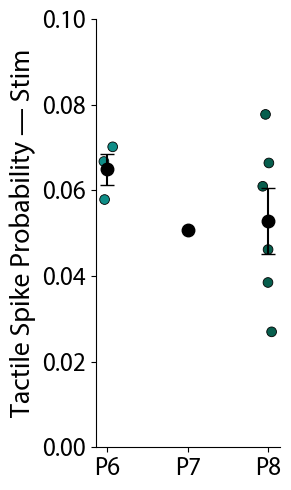

Résultat du test de Kruskal-Wallis :
Statistique = 1.636, p-value = 0.4412


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrer les données à la période "Stim"
df_stim = df[df['period'] == 'Stim'].copy()

# Supprimer les doublons par directory pour éviter répétitions (si besoin)
df_stim_unique = df_stim.groupby(['directory', 'age'], observed=False)['sdf'].mean().reset_index()

# Réorganiser pour avoir les animaux en lignes et les âges en colonnes (facultatif, utile pour lecture ou stats)
sdf_pivot = df_stim_unique.pivot(index='directory', columns='age', values='sdf').reset_index()

# Affichage des résultats
print("SDF moyen par animal et par âge pendant la période 'Stim' :")
print(sdf_pivot)


# Calculer moyenne et SEM par âge
mean_sem = df_stim_unique.groupby('age', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem')
).reset_index()


# Couleurs par âge
age_colors = {'P6': '#0f8d87', 'P7': '#18e0d3', 'P8': '#075e4d'}

plt.figure(figsize=(3, 5))

# Points individuels par directory
sns.stripplot(
    data=df_stim_unique,
    x='age',
    y='sdf',
    hue='age',
    palette=age_colors,
    size=7,
    jitter=True,
    edgecolor='k',
    linewidth=0.6,
    zorder=1,
    order=['P6', 'P7', 'P8']  # <-- forcer l'ordre des âges
)

# Ajouter les moyennes ± SEM
for idx, row in mean_sem.iterrows():
    x = ['P6', 'P7', 'P8'].index(row['age'])  # <- Position x basée sur l’ordre
    y = row['mean_sdf']
    yerr = row['sem_sdf']
    plt.errorbar(
        x,
        y,
        yerr=yerr,
        fmt='o',
        color='black',
        capsize=5,
        markersize=9,
        zorder=2
    )


# Mise en forme
plt.ylabel("Tactile Spike Probability — Stim")
plt.xlabel("")
plt.ylim(0, 0.1)
sns.despine()
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Age_SDF_WT_thq_cool_TS.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Age_SDF_WT_thq_cool_TS.svg'), format='svg', dpi=300)

plt.show()


import pingouin as pg
import scikit_posthocs as sp
import scipy.stats as stats

# Filtrer la période Stim et extraire les valeurs
df_stim = df[df['period'] == 'Stim'].copy()
df_stim_unique = df_stim.groupby(['directory', 'age'], observed=False)['sdf'].mean().reset_index()

# ------------------- Kruskal-Wallis ------------------- #
kruskal_result = stats.kruskal(
    *[df_stim_unique[df_stim_unique['age'] == age]['sdf'].dropna() for age in ['P6', 'P7', 'P8']]
)

print("Résultat du test de Kruskal-Wallis :")
print(f"Statistique = {kruskal_result.statistic:.3f}, p-value = {kruskal_result.pvalue:.4f}")


#

# SDF Analysis by Sex

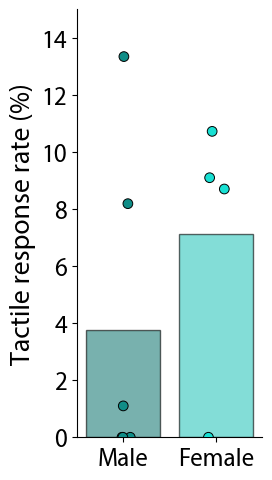

Résultat du test de Mann-Whitney U (M vs F) :
U = 7.500, p-value = 0.3789


C:\Users\zayan\AppData\Local\Temp\ipykernel_29276\3534015608.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = response_percentsex.groupby('sex')['response']


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem

# Charger les données contra uniquement
WT_cool_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_WT_resp_rate.xlsx"
df_WT_cool_cont = pd.read_excel(WT_cool_cont_path)

# Calcul du pourcentsex de réponse pour chaque directory
response_percentsex = df_WT_cool_cont.groupby(['directory'])['response'].agg(
    lambda x: (x.sum() / len(x)) * 100
).reset_index()

# Ajouter l'âge depuis 'file_name' ou directement depuis df_WT_tac_cont
file_sex_map = df_WT_cool_cont[['directory', 'sex']].drop_duplicates()
response_percentsex = response_percentsex.merge(file_sex_map, on='directory', how='left')

# Définir l'ordre des âges correct : P6, P7, P8
sex_order = ['M', 'F']
response_percentsex['sex'] = pd.Categorical(response_percentsex['sex'], categories=sex_order, ordered=True)

# Calcul des moyennes et SEM par âge
mean_sem_by_sex = response_percentsex.groupby('sex', observed=True)['response'].agg(['mean', sem]).reset_index()
mean_sem_by_sex.rename(columns={'mean': 'response_mean', 'sem': 'response_sem'}, inplace=True)

# Couleurs personnalisées (modifiable à ton goût)
sex_colors = {'M': '#0f8d87', 'F': '#18e0d3'}


# Création de la figure
plt.figure(figsize=(3, 5))

# Barplot (moyenne ± SEM)
sns.barplot(
    data=mean_sem_by_sex, x='sex', y='response_mean', hue='sex',
    palette=sex_colors, capsize=0.2, edgecolor='k', alpha=0.6,
    err_kws={'color': 'k', 'linewidth': 1.5},
    legend=False
)


# Ajouter les points individuels par directory
sns.stripplot(
    data=response_percentsex, x='sex', y='response', hue='sex',
    palette=sex_colors, s=7, jitter=True, dodge=False,
    edgecolor='k', linewidth=0.7,
    legend=False
)


# Personnalisation
plt.ylabel("Tactile response rate (%)")
plt.xlabel("")
plt.xticks([0, 1], ['Male', 'Female'])
plt.ylim(0, 15)

# Nettoysex des bordures
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()


#Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Sex_response_rate_WT_thq_cool.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Sex_response_rate_WT_thq_cool.svg'), format='svg', dpi=300)

plt.show()



################# Stat Kruskal-Wallis #################

# Extraire les groupes de données pour chaque âge
grouped = response_percentsex.groupby('sex')['response']
M_data = grouped.get_group('M').dropna()
F_data = grouped.get_group('F').dropna()

mann_result = stats.mannwhitneyu(M_data, F_data, alternative='two-sided')
print("Résultat du test de Mann-Whitney U (M vs F) :")
print(f"U = {mann_result.statistic:.3f}, p-value = {mann_result.pvalue:.4f}")



C:\Users\zayan\AppData\Local\Temp\ipykernel_1140\2004320743.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(['directory', 'period', 'sex'])['sdf'].mean().reset_index()


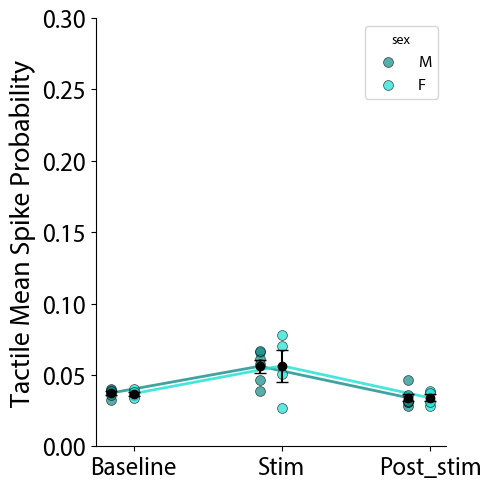


Résumé par période et sex :
      period sex  mean_sdf   sem_sdf
0   Baseline   M  0.037375  0.001220
1   Baseline   F  0.036926  0.001400
2       Stim   M  0.056090  0.004670
3       Stim   F  0.056376  0.011343
4  Post_stim   M  0.034055  0.002639
5  Post_stim   F  0.033825  0.002455

Nombre d'animaux uniques par sex :
M : 6
F : 4


C:\Users\zayan\AppData\Local\Temp\ipykernel_1140\2004320743.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_animals_by_sex = df[['directory', 'sex']].drop_duplicates().groupby('sex').size().to_dict()


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import scikit_posthocs as sp

# ------------------- CHARGEMENT DES DONNÉES ------------------- #

# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes et des sexs
period_order = ['Baseline', 'Stim', 'Post_stim']
sex_order = ['M', 'F']

df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)
df['sex'] = pd.Categorical(df['sex'], categories=sex_order, ordered=True)

# Calculer la moyenne de sdf par directory et period
df_grouped = df.groupby(['directory', 'period', 'sex'])['sdf'].mean().reset_index()

# Moyenne + SEM par combinaison période-sex (pour le graph)
mean_sem_by_sex = df_grouped.groupby(['period', 'sex'], observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem')
).reset_index()

# ------------------- PLOT ------------------- #

# Définir les couleurs pour chaque sex
sex_colors = {'M': '#0f8d87', 'F': '#18e0d3'}

# Position x des périodes
period_positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
offset = 0.15  # pour espacer les sexs

plt.figure(figsize=(5, 5))

# Tracer les points individuels avec décalsex par sex
for i, period in enumerate(period_order):
    for j, sex in enumerate(sex_order):
        x = period_positions[period] + (j - 1) * offset  # -offset, 0, +offset
        subset = df_grouped[(df_grouped['period'] == period) & (df_grouped['sex'] == sex)]
        plt.scatter(
            [x] * len(subset),
            subset['sdf'],
            color=sex_colors[sex],
            edgecolor='k',
            linewidth=0.5,
            alpha=0.7,
            s=50,
            label=sex if i == 0 else "",  # éviter doublons dans légende
            zorder=1
        )

# Ajouter les moyennes + SEM par période et sex
for i, period in enumerate(period_order):
    for j, sex in enumerate(sex_order):
        x = period_positions[period] + (j - 1) * offset
        row = mean_sem_by_sex[(mean_sem_by_sex['period'] == period) & (mean_sem_by_sex['sex'] == sex)]
        if not row.empty:
            y = row['mean_sdf'].values[0]
            yerr = row['sem_sdf'].values[0]
            plt.errorbar(
                x,
                y,
                yerr=yerr,
                fmt='o',
                color='black',
                capsize=4,
                zorder=3
            )

# Ajouter les lignes de connexion entre les moyennes pour chaque sex
for j, sex in enumerate(sex_order):
    xs = []
    ys = []
    for period in period_order:
        row = mean_sem_by_sex[(mean_sem_by_sex['period'] == period) & (mean_sem_by_sex['sex'] == sex)]
        if not row.empty:
            x = period_positions[period] + (j - 1) * offset
            y = row['mean_sdf'].values[0]
            xs.append(x)
            ys.append(y)
    if len(xs) == len(period_order):
        plt.plot(xs, ys, color=sex_colors[sex], linewidth=2, zorder=0, alpha=0.8)

# Définir les positions X pour les ticks
x_ticks = [period_positions[p] for p in period_order]
plt.xticks(ticks=x_ticks, labels=period_order)
plt.ylim(0, 0.3)
plt.ylabel("Tactile Mean Spike Probability")
plt.xlabel("")
plt.legend(title="sex")
plt.tight_layout()

# Nettoysex esthétique du graphe
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Sex_SDF_WT_thq_cool_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Sex_SDF_WT_thq_cool_period.svg'), format='svg', dpi=300)


plt.show()

# ------------------- TABLEAUX DE SYNTHÈSE ------------------- #

# Moyenne/SEM/N par période et sex
summary_by_period_sex = mean_sem_by_sex.copy()

print("\nRésumé par période et sex :")
print(summary_by_period_sex)

# Nombre d'animaux uniques par sex
n_animals_by_sex = df[['directory', 'sex']].drop_duplicates().groupby('sex').size().to_dict()
summary_by_period_sex['N_animals'] = summary_by_period_sex['sex'].map(n_animals_by_sex)
print("\nNombre d'animaux uniques par sex :")
for sex, n in n_animals_by_sex.items():
    print(f"{sex} : {n}")


SDF moyen par animal et par sexe pendant la période 'Stim' :
sex      directory         M         F
0       2024.01.31       NaN  0.026953
1       2024.02.06       NaN  0.077725
2       2024.02.23  0.066383       NaN
3       2024.03.01  0.046166       NaN
4       2024.03.05  0.038477       NaN
5       2024.04.03  0.060943       NaN
6       2024.05.22       NaN  0.070155
7    2024.05.28_M1  0.057845       NaN
8    2024.05.28_M2  0.066725       NaN
9       2024.05.29       NaN  0.050670


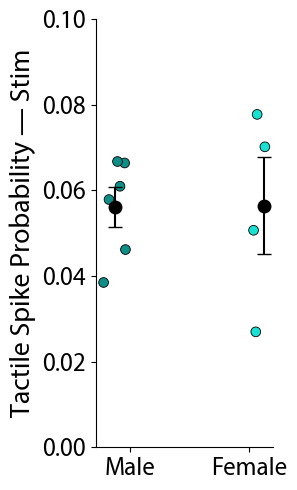

Résultat du test de Mann-Whitney U (M vs F) :
U = 10.000, p-value = 0.7619


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats

# ---------------------- Filtrage et préparation ---------------------- #

# Filtrer les données à la période "Stim"
df_stim = df[df['period'] == 'Stim'].copy()

# Calcul du SDF moyen par animal (directory) et par sexe
df_stim_unique = df_stim.groupby(['directory', 'sex'], observed=False)['sdf'].mean().reset_index()

# Réorganiser pour affichage (facultatif)
sdf_pivot = df_stim_unique.pivot(index='directory', columns='sex', values='sdf').reset_index()
print("SDF moyen par animal et par sexe pendant la période 'Stim' :")
print(sdf_pivot)

# ---------------------- Plot avec points + moyennes/SEM ---------------------- #

# Moyenne et SEM par sexe
mean_sem = df_stim_unique.groupby('sex', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem')
).reset_index()

# Couleurs personnalisées
sex_colors = {'M': '#0f8d87', 'F': '#18e0d3'}

plt.figure(figsize=(3, 5))

# Affichage des points (un par animal/directory)
sns.stripplot(
    data=df_stim_unique,
    x='sex',
    y='sdf',
    hue='sex',
    palette=sex_colors,
    size=7,
    jitter=True,
    edgecolor='k',
    linewidth=0.6,
    zorder=1
)

# Moyenne ± SEM
for i, row in mean_sem.iterrows():
    x = row['sex']
    y = row['mean_sdf']
    yerr = row['sem_sdf']
    plt.errorbar(
        x,
        y,
        yerr=yerr,
        fmt='o',
        color='black',
        capsize=5,
        markersize=9,
        zorder=2
    )

# Mise en forme du plot
plt.ylabel("Tactile Spike Probability — Stim")
plt.ylim(0, 0.1)
plt.xlabel("")
plt.xticks([0.1, 0.9], ['Male', 'Female'])
sns.despine()
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Sex_SDF_WT_thq_cool_TS.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Sex_SDF_WT_thq_cool_TS.svg'), format='svg', dpi=300)

plt.show()

# ---------------------- Test statistique Mann-Whitney ---------------------- #

group_M = df_stim_unique[df_stim_unique['sex'] == 'M']['sdf'].dropna()
group_F = df_stim_unique[df_stim_unique['sex'] == 'F']['sdf'].dropna()


mann_result = stats.mannwhitneyu(group_M, group_F, alternative='two-sided')
print("Résultat du test de Mann-Whitney U (M vs F) :")
print(f"U = {mann_result.statistic:.3f}, p-value = {mann_result.pvalue:.4f}")



#

#

# pour filtre savgol de scipy (savgol_ 101,3)